In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Consistent visual style throughout the notebook
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [3]:
# Load the dataset from a CSV file
path = 'data/research_centers.csv'
data = pd.read_csv(path)

data.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


## Exploratory Data Analysis (EDA)

### Data Quality Check

In [4]:
# Check the shape of the dataset
print(f'Dataset shape: {data.shape}')

Dataset shape: (50, 10)


In [5]:
# Check the data types of each column
print(f"Data types:\n{data.dtypes}")

Data types:
researchCenterId            object
researchCenterName          object
city                        object
latitude                   float64
longitude                  float64
internalFacilitiesCount      int64
hospitals_10km               int64
pharmacies_10km              int64
facilityDiversity_10km     float64
facilityDensity_10km       float64
dtype: object


In [6]:
# display summary statistics for numerical columns
print("Summary statistics for numerical columns:")
display(data.describe(include=[np.number]).T)

Summary statistics for numerical columns:


,count,mean,std,min,25%,50%,75%,max
latitude,50.0,50.542770,0.320289,50.007100,50.240375,50.635350,50.831475,50.994600
longitude,50.0,-1.554638,0.253853,-1.976900,-1.747225,-1.561000,-1.374175,-1.049300
internalFacilitiesCount,50.0,5.660000,3.146816,1.000000,3.000000,5.000000,8.750000,11.000000
hospitals_10km,50.0,1.860000,1.340271,0.000000,1.000000,2.000000,3.000000,4.000000
pharmacies_10km,50.0,2.240000,1.684988,0.000000,1.000000,2.000000,3.000000,5.000000
facilityDiversity_10km,50.0,0.568843,0.249511,0.119515,0.344145,0.585503,0.800489,0.992984
facilityDensity_10km,50.0,0.321164,0.182562,0.056541,0.173814,0.297584,0.476387,0.697016


In [7]:
# Display categorical summary statistics
print("Summary statistics for categorical columns:")
display(data.describe(include=[object]).T)

Summary statistics for categorical columns:


,count,unique,top,freq
researchCenterId,50,50,RC-014,1
researchCenterName,50,50,Research Center 14,1
city,50,5,City 3,14


In [8]:
# Total number of research centers
total_centers = data['researchCenterId'].nunique()
print(f'Total number of research centers: {total_centers}')

Total number of research centers: 50


In [9]:
# Total number of cities
total_cities = data['city'].nunique()
print(f'Total number of cities: {total_cities}')

Total number of cities: 5


In [10]:
# Check for duplicate ids
duplicate_ids = data['researchCenterId'].duplicated().sum()
print(f'Number of duplicate ids: {duplicate_ids}')

Number of duplicate ids: 0


In [11]:
missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64


### Data Distribution 

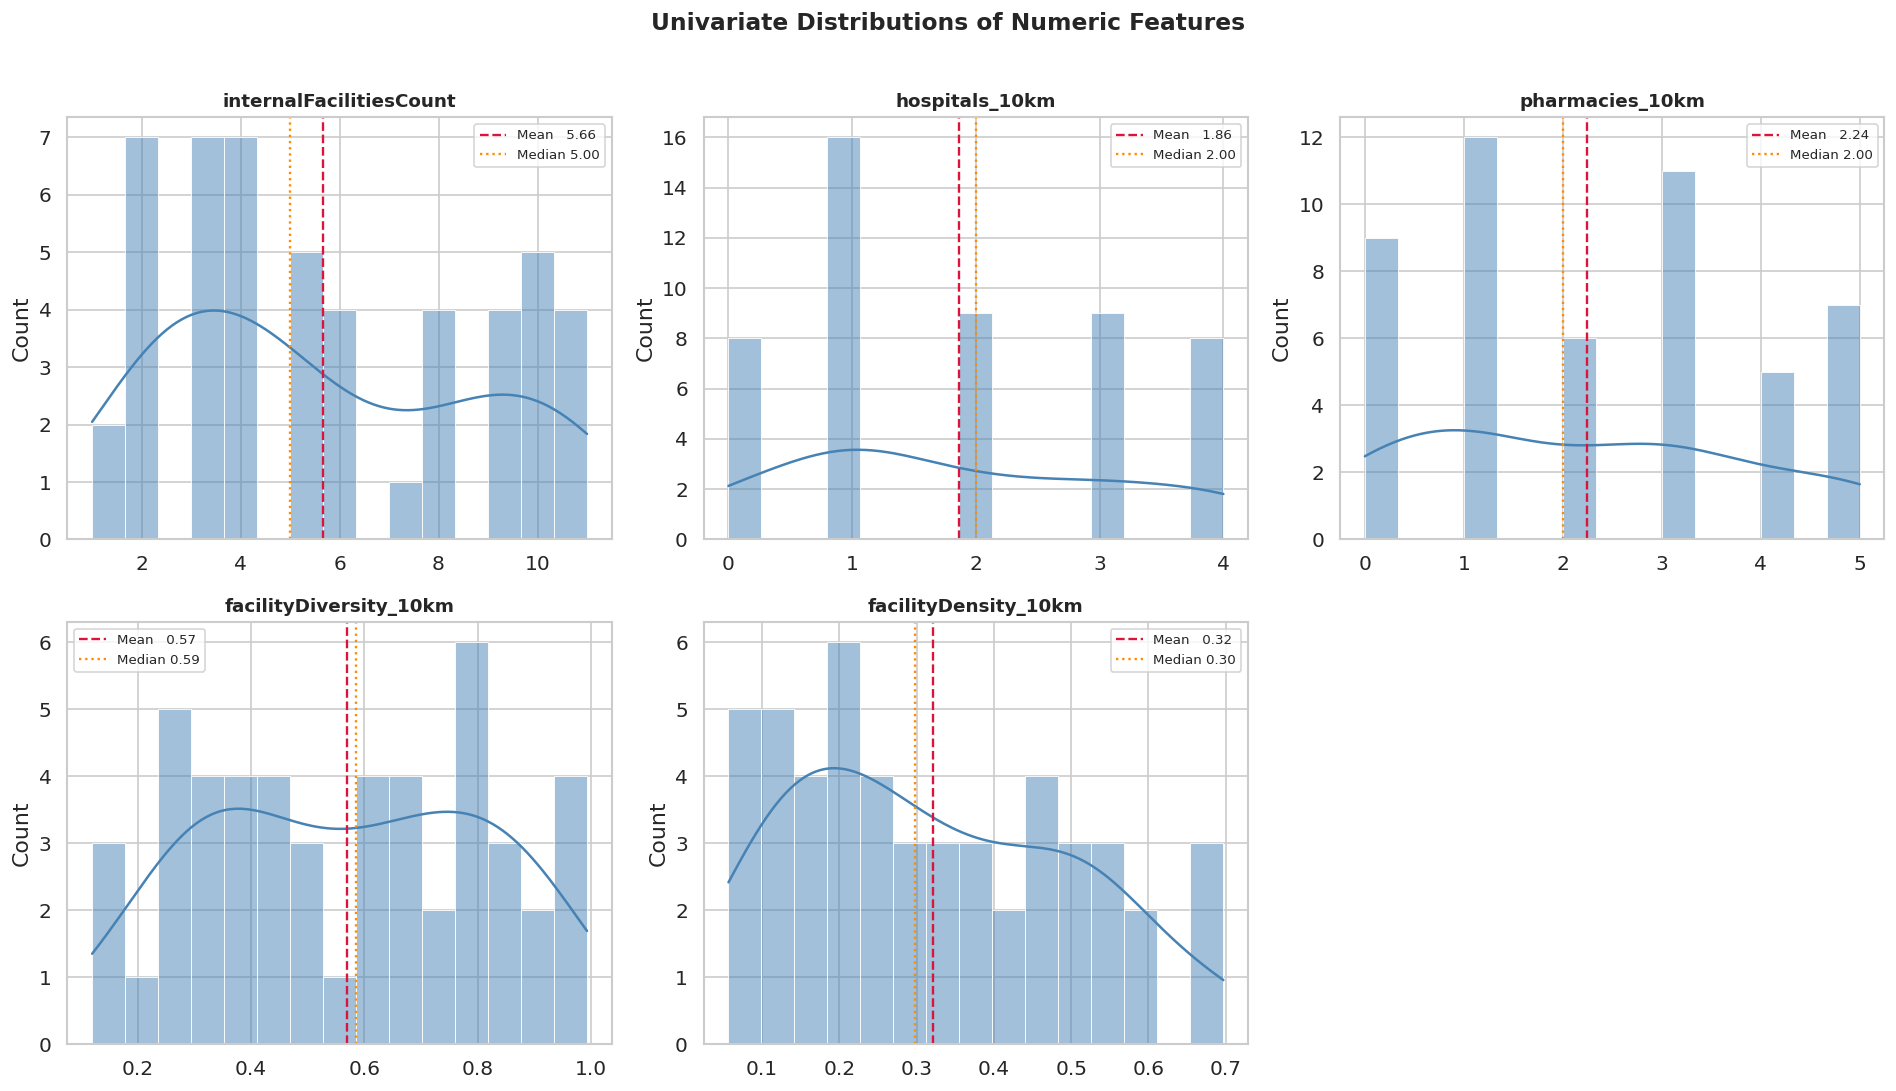

In [12]:
# --- Univariate Analysis of Numeric Features ---

numeric_features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    ax = axes[i]
    sns.histplot(
        data[col],
        bins=15,
        kde=True,           # overlay kernel density estimate
        color="steelblue",
        ax=ax,
        edgecolor="white",
        linewidth=0.5,
    )

    # Mark the mean and median for quick visual comparison
    mean_val   = data[col].mean()
    median_val = data[col].median()
    ax.axvline(mean_val,   color="crimson",      linestyle="--",
               linewidth=1.4, label=f"Mean   {mean_val:.2f}")
    ax.axvline(median_val, color="darkorange",   linestyle=":",
               linewidth=1.4, label=f"Median {median_val:.2f}")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)

# Hide the unused 6th subplot
axes[-1].set_visible(False)

fig.suptitle(
    "Univariate Distributions of Numeric Features",
    fontsize=14, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("eda_visuals/eda_univariate_distributions.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS SO FAR

Internal Facilities Count

- The mean (5.66) and median (5.0) are close but not identical, a slight right skew, meaning a handful of centers have significantly more internal facilities pulling the mean upward
- The standard deviation of 3.15 relative to a mean of 5.66 is large, this is a high-variance feature, meaning centers vary considerably in internal infrastructure
- The IQR (3.0 to 8.75) captures the middle 50% of centers, this wide spread strongly suggests natural groupings will emerge in clustering
Clustering implication: This feature will be one of the primary drivers for separating Premium (high count) from Basic (low count) centers

Hospitals_10km

- Integer values only (0, 1, 2, 3, 4), discrete count variable
- The minimum of 0 means some centers have no hospitals within 10 km, a potential marker of isolated or rural locations
- Mean ≈ Median (1.86 vs 2.0), near-symmetric distribution, limited skew
- The standard deviation of 1.34 out of a max of 4 is proportionally large, there is meaningful variation in hospital access across centers
- Clustering implication: Centers with 3–4 hospitals nearby are likely to end up in the Premium cluster; 0 hospitals likely in Basic

Pharmacies_10km

- Similar pattern to hospitals, discrete integer, minimum of 0, maximum of 5
- The standard deviation of 1.68 is the largest relative spread among the count-based features, pharmacy access varies more than hospital access
- Mean slightly above median (2.24 vs 2.0), minor right skew, suggesting some well-served centers pull the average up
- Clustering implication: High pharmacy counts (4–5) correlate with well-served research environments; combined with hospital count this forms a strong external access signal

Facility Diversity_10km

- This is a bounded 0–1 index, confirmed valid (no values below 0 or above 1)
- Mean ≈ Median (0.57 ≈ 0.59), very symmetric distribution, confirmed by the above histogram showing a roughly bell-shaped spread
- The standard deviation of 0.25 on a 0–1 scale is substantial, centers span the full diversity spectrum from low (0.12) to near-perfect (0.99)
- IQR: 0.34 to 0.80, the middle half of centers span a wide diversity range, reinforcing that this feature meaningfully differentiates quality
- Clustering implication: High diversity scores (>0.80) indicate Premium centers surrounded by varied healthcare infrastructure; low scores (<0.35) mark Basic centers

Facility Density_10km

- Mean slightly above median (0.32 vs 0.30), mild right skew, a few high-density locations pull the average up
- The maximum of 0.70 is exactly twice the mean, confirms a right tail of well-served, high-density locations
- Standard deviation of 0.18 on a range of 0.06–0.70 suggests moderate spread, not as extreme as internal facilities count but still meaningfully variable
- Clustering implication: High density (>0.50) combined with high diversity would strongly indicate a Premium environment

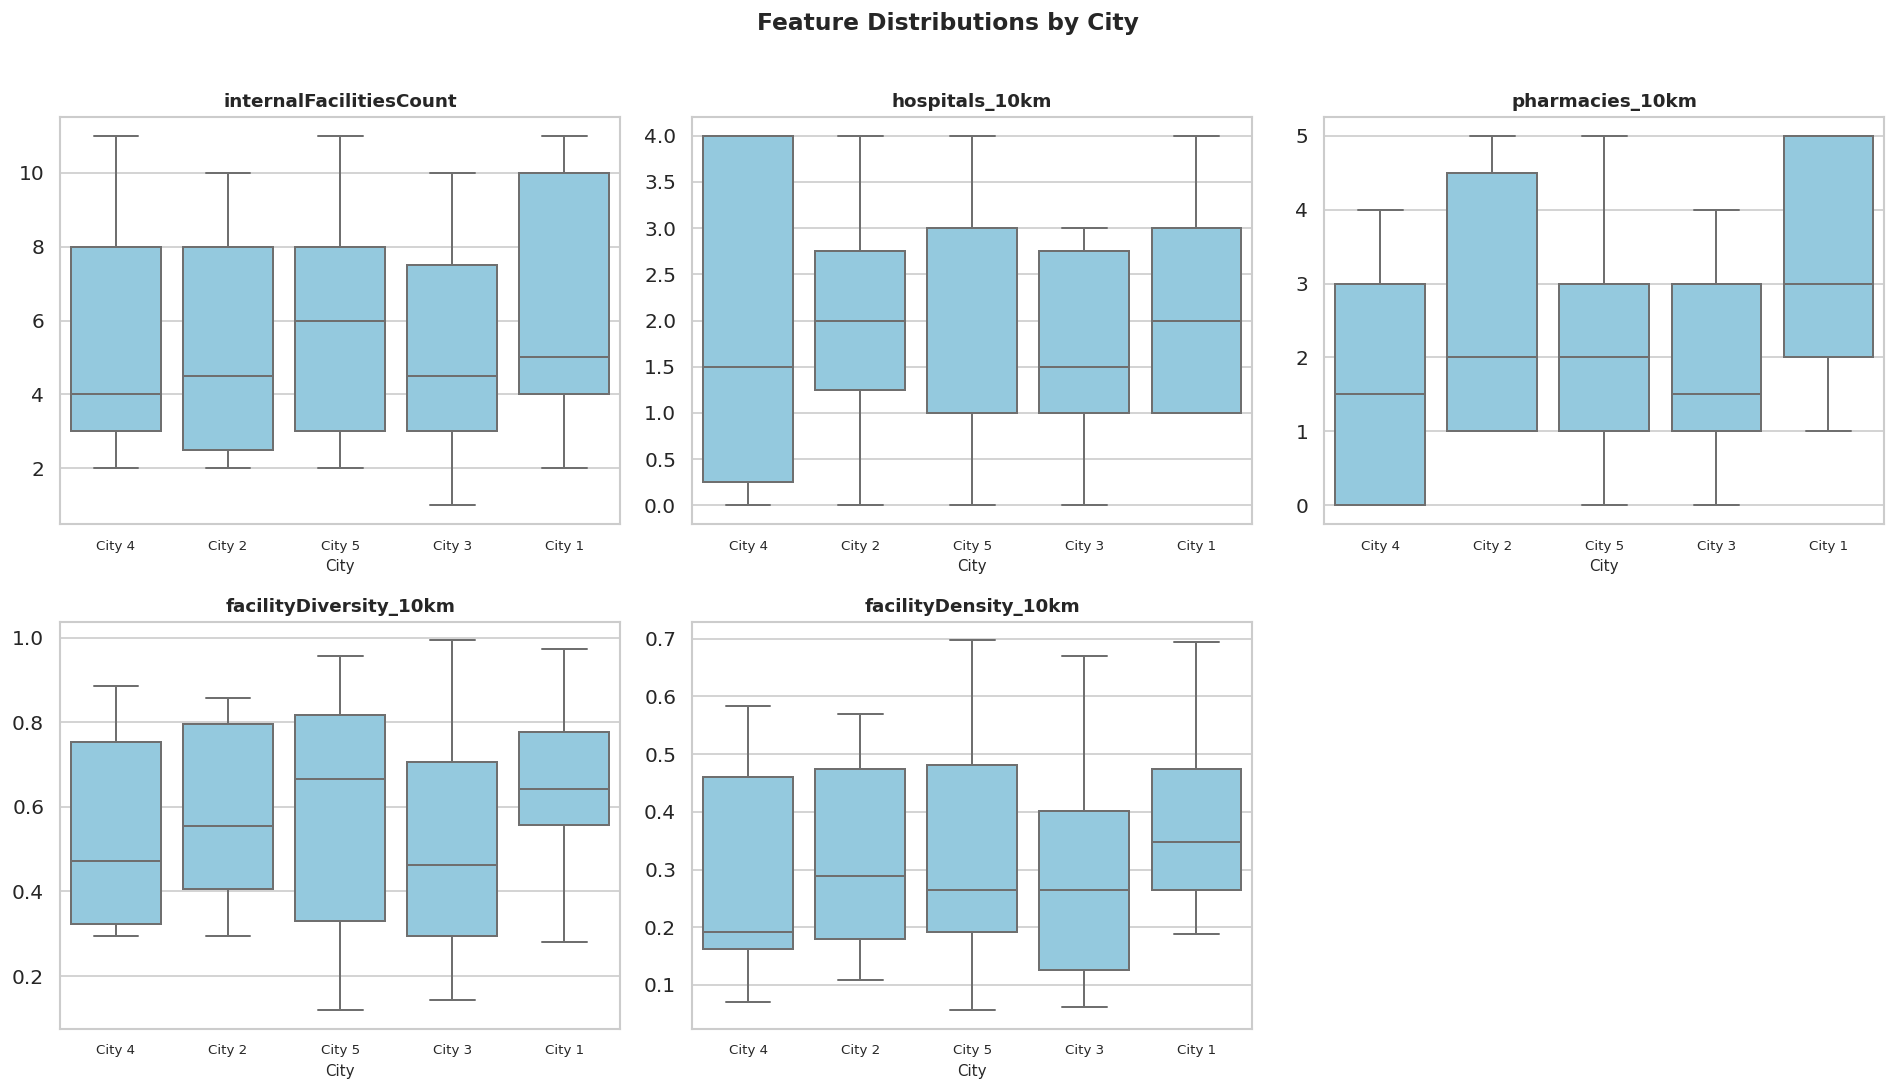

In [13]:
# --- Bivariate Analysis: Boxplots by City ---

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    ax = axes[i]
    sns.boxplot(
        data=data,
        x="city",
        y=col,
        color="skyblue",
        linewidth=1.2,
        flierprops=dict(marker="o", markerfacecolor="red",
                        markersize=4, alpha=0.6),
        ax=ax,
    )
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("City", fontsize=9)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=8)

axes[-1].set_visible(False)

fig.suptitle(
    "Feature Distributions by City",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("eda_visuals/eda_boxplots_by_city.png", bbox_inches="tight")
plt.show()

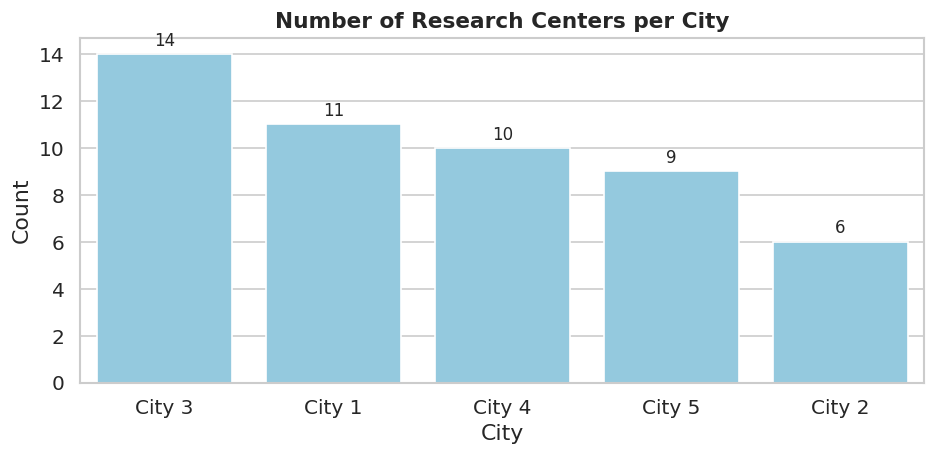

In [14]:
# --- Categorical Analysis: Count of Research Centers per City ---

city_counts = data["city"].value_counts().reset_index()
city_counts.columns = ["city", "count"]   # explicitly setting column names

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=city_counts,
    x="city",
    y="count",
    color="skyblue",
    ax=ax,
    edgecolor="white",
)
ax.set_title("Number of Research Centers per City",
             fontsize=13, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Count")

# Annotate bars with exact counts
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.savefig("eda_visuals/eda_centers_per_city.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

- City 3 has 2.3× more centers than City 2, the most imbalanced pair
- Cities 1, 4, and 5 are relatively balanced (9–11 centers each)
- No city has zero representation, all five contribute to the clustering
- Business implication: City 3 having the most centers but the lowest average internal facility count (5.07) suggests that quantity of centers does not equal quality, a finding only visible when combining this chart with the heatmap

### Correlations

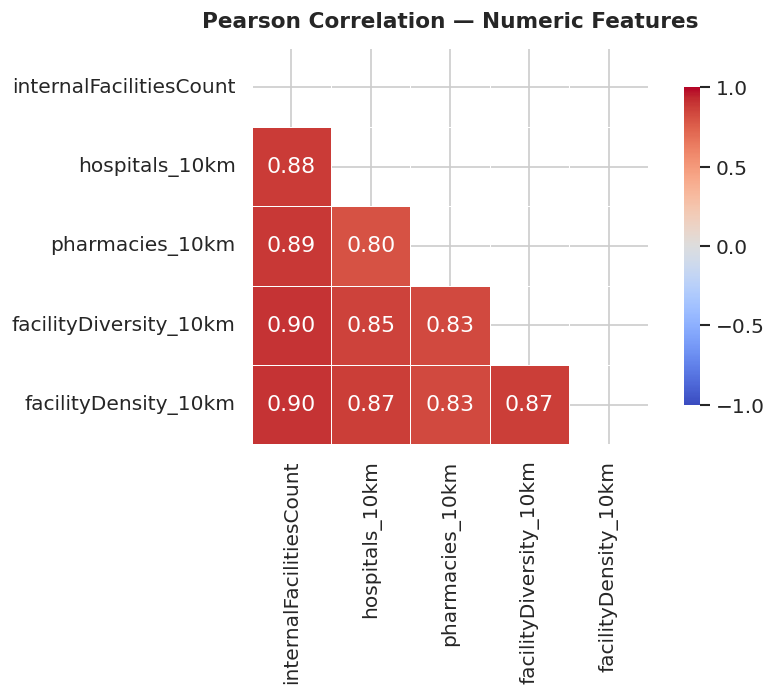

In [15]:
# --- Correlation Heatmap of Numeric Features ---

corr_matrix = data[numeric_features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title(
    "Pearson Correlation — Numeric Features",
    fontsize=13, fontweight="bold", pad=12
)
plt.tight_layout()
plt.savefig("eda_visuals/eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

internalFacilitiesCount ↔ hospitals_10km = 0.88

- Very strong positive correlation
- Centers with more internal labs and workstations tend to be located near more hospitals
- This likely reflects an urban co-location effect, well-funded research centers choose locations near medical infrastructure
- Not redundant, internal count measures the center itself; hospitals measure the surrounding environment. They capture different dimensions of quality

internalFacilitiesCount ↔ pharmacies_10km = 0.89

- Near-identical strength to the hospital correlation
- Again reflects co-location: research centers with greater internal capacity tend to be in more developed healthcare zones
- Both hospital and pharmacy count are strong external proxies for center quality

internalFacilitiesCount ↔ facilityDiversity_10km = 0.90

- The strongest pairing with internal count
- A center with many internal facilities is almost always in a diverse external healthcare environment
- This confirms the working hypothesis from the scatter plot that internal and external quality move together

internalFacilitiesCount ↔ facilityDensity_10km = 0.90

- Equal strength to diversity (both 0.90)
- Higher internal facility count = denser surrounding healthcare environment
- Together, diversity and density provide near-identical information about internal quality

facilityDiversity_10km ↔ facilityDensity_10km = 0.87

- The highest inter-feature correlation that does not involve internal count
- These two features are strongly related, an area with dense healthcare will naturally have more varied types of healthcare (diverse)
- Potential redundancy concern: With r = 0.87, one might argue for dropping one of these features. However, they are not identical, a dense but specialised area (e.g., only pharmacies) would score high on density but lower on diversity. Keeping both adds nuance to the clustering

hospitals_10km ↔ pharmacies_10km = 0.80

- Strong but not as tight as other pairs
- This makes intuitive sense, an area near many hospitals will usually have pharmacies, but the exact number of each can differ (a hospital district vs a high-street area)

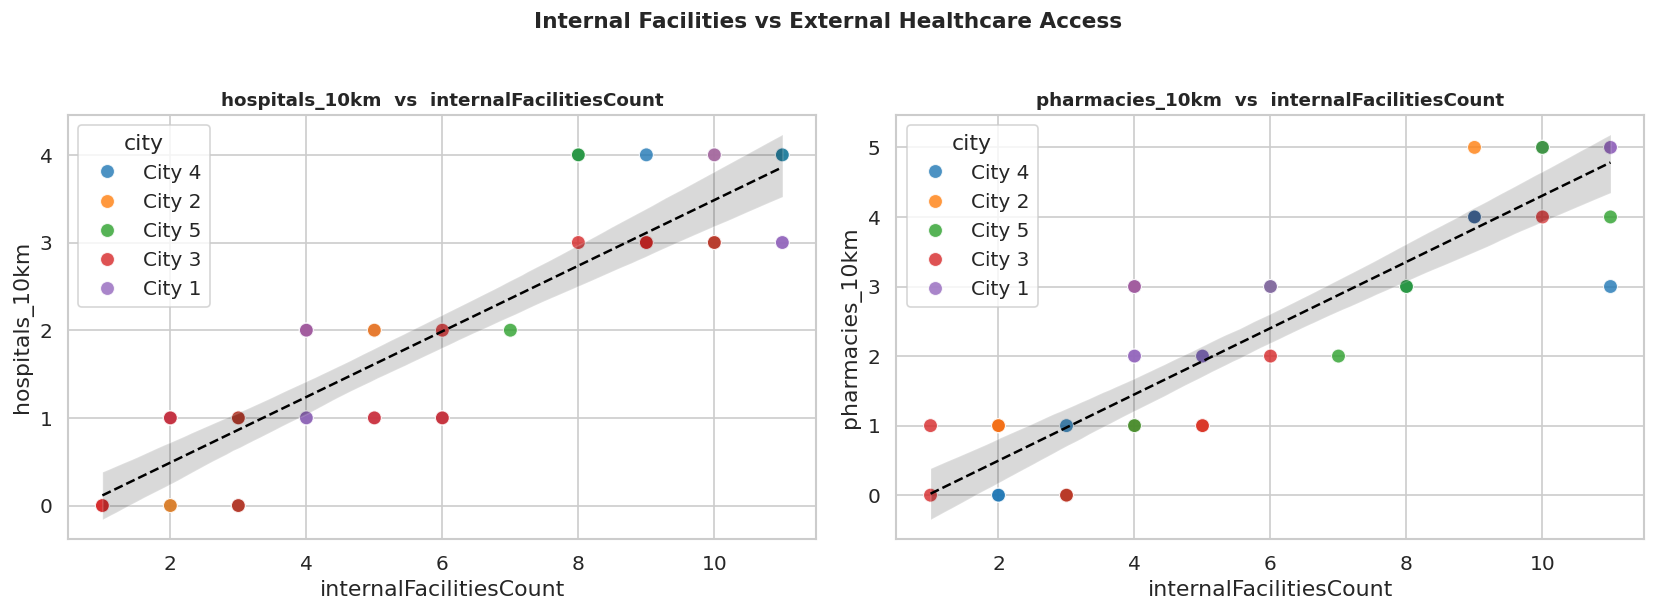

In [16]:
# --- Bivariate Analysis: Scatter Plots of Internal Facilities vs External Access (hospital & pharmacy access)---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_pairs = [
    ("internalFacilitiesCount", "hospitals_10km"),
    ("internalFacilitiesCount", "pharmacies_10km"),
]

for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=data,
        x=x_col,
        y=y_col,
        hue="city",
        palette="tab10",
        s=70,
        alpha=0.8,
        ax=ax,
    )

    # Regression trend line (no hue) to show overall direction
    sns.regplot(
        data=data,
        x=x_col,
        y=y_col,
        scatter=False,
        color="black",
        line_kws={"linewidth": 1.5, "linestyle": "--"},
        ax=ax,
    )
    ax.set_title(f"{y_col}  vs  {x_col}", fontsize=11, fontweight="bold")

plt.suptitle(
    "Internal Facilities vs External Healthcare Access",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("eda_visuals/eda_scatter_internal_vs_external.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

hospitals_10km vs internalFacilitiesCount

- Strong positive linear trend, the dashed regression line has a clear upward slope with a narrow confidence band
- Centers with 8–11 internal facilities almost universally have 3–4 nearby hospitals
- Centers with 1–3 internal facilities are clustered near 0–1 hospitals
- The relationship holds across all cities (colours are mixed throughout the plot, not clustered to one region)
- The tight confidence band around the regression line confirms this is a reliable linear relationship (consistent with r = 0.88 from the correlation heatmap)

pharmacies_10km vs internalFacilitiesCount

- Even stronger linear trend than hospitals, consistent with r = 0.89
- The confidence band is slightly wider at high facility counts (8–11), suggesting more variability at the top end, some high-facility centers have 3 pharmacies, others have 5
- City colours are mixed throughout, both low and high quality centers exist in all cities, confirming city is not the primary determinant of quality
- The clear linear relationship across the full range means both variables are capturing the same underlying quality dimension

Combined scatter plot conclusion:

Both plots confirm that internal Facilities Count and external healthcare access (hospitals and pharmacies) rise together consistently. A center investing in internal infrastructure tends to locate where external healthcare infrastructure is also strong. This validates treating all five features together as a composite quality signal.

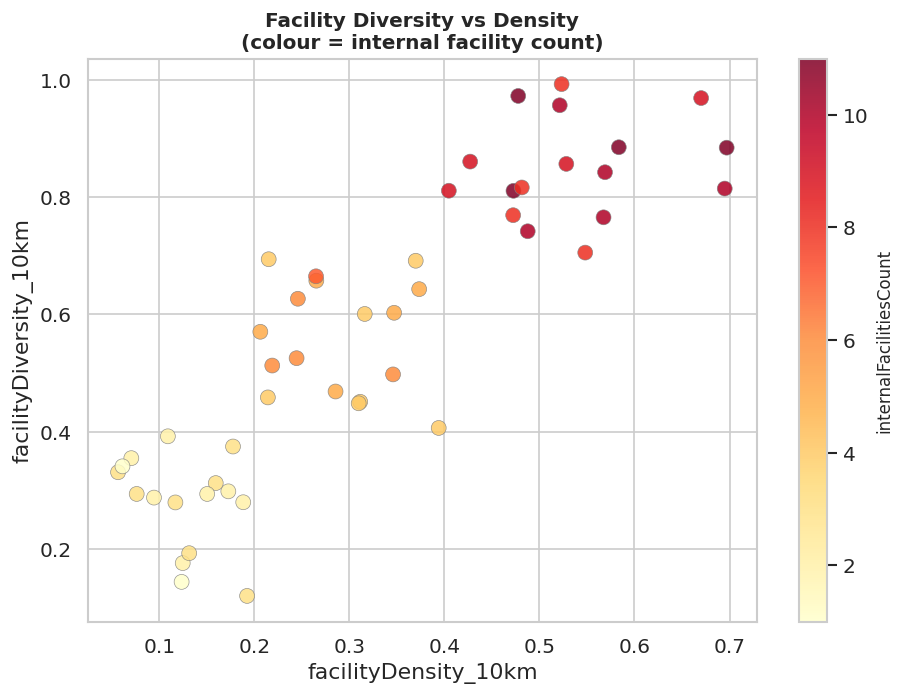

In [17]:
# --- Bivariate Analysis: Facility Diversity vs Density (colour = internal facility count) ---

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    data["facilityDensity_10km"],
    data["facilityDiversity_10km"],
    c=data["internalFacilitiesCount"],
    cmap="YlOrRd",
    s=80,
    alpha=0.85,
    edgecolors="grey",
    linewidth=0.4,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("internalFacilitiesCount", fontsize=10)
ax.set_xlabel("facilityDensity_10km")
ax.set_ylabel("facilityDiversity_10km")
ax.set_title(
    "Facility Diversity vs Density\n(colour = internal facility count)",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("eda_visuals/eda_diversity_vs_density.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

This single chart carries three dimensions of information simultaneously:

- X-axis: facilityDensity_10km 
- Y-axis: facilityDiversity_10km 
- Colour: internalFacilitiesCount (yellow = low, dark red = high)

Observations:

Top-right region (high density + high diversity):

- Points here are almost exclusively dark red (internal count 8–11)
- This is the Premium cluster region, centers that score well on both external dimensions AND have high internal capacity
- The cluster is tight and well-separated from the bottom-left

Bottom-left region (low density + low diversity):

- Points are yellow to light orange (internal count 1–4)
- This is the Basic cluster region, poor external access and limited internal infrastructure
- The grouping is also relatively compact

Middle region (moderate density + moderate diversity):

- Points range from orange to light red (internal count 4–8)
- This is the Standard cluster region, adequate but not exceptional on any dimension
- This region is more spread out, which reflects the expected challenge of separating Standard from the other two tiers

Critical insight:

The plot shows three visually emergent groups even without running K-Means. This is powerful validation that:

1. The features are appropriate for three-cluster classification
2. A K=3 K-Means model is likely to find clean, meaningful separations
3. The clusters will correspond logically to quality tiers (not arbitrary mathematical groupings)

### City Pattern

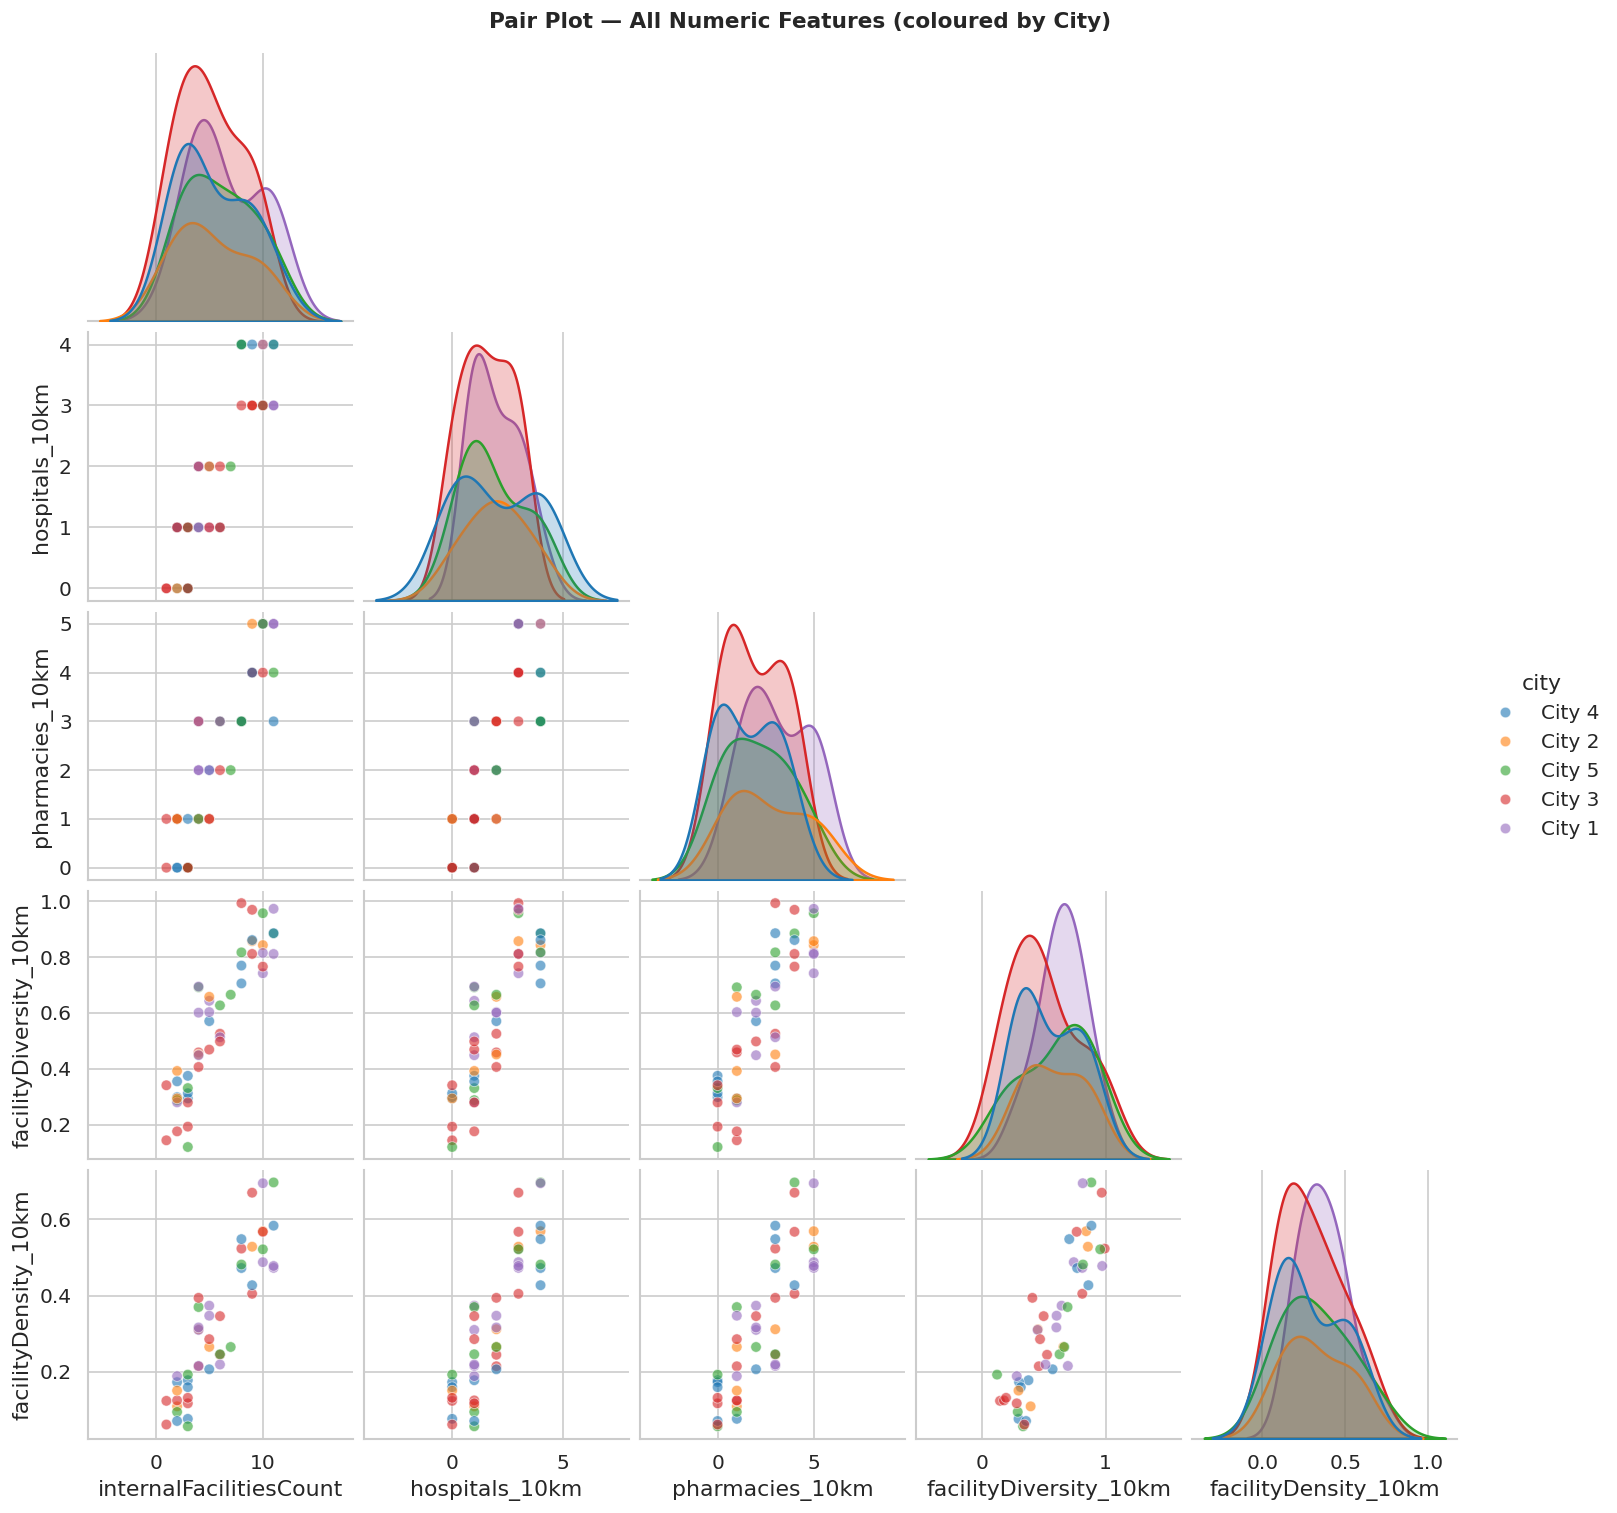

In [18]:
# --- Pair Plot of Numeric Features (coloured by City) ---

pair_data = data[numeric_features + ["city"]].copy()

pair_grid = sns.pairplot(
    pair_data,
    hue="city",
    palette="tab10",
    diag_kind="kde",        # KDE on diagonal instead of histogram for clarity
    plot_kws={"alpha": 0.6, "s": 40},
    diag_kws={"linewidth": 1.5},
    corner=True,            # only lower triangle, avoids redundancy
)
pair_grid.figure.suptitle(
    "Pair Plot — All Numeric Features (coloured by City)",
    y=1.01, fontsize=13, fontweight="bold"
)
pair_grid.savefig("eda_visuals/eda_pairplot.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATIONS

The pair plot provides the most comprehensive view, it shows every pairwise combination of the five features simultaneously.

Key patterns:

Diagonal KDE plots (each feature's distribution per city):

- The KDE curves for each city substantially overlap on every feature
- This confirms that no single city dominates any cluster, all cities contribute centers to all tiers
- City 3 (red) tends to have wider, flatter distributions, reflecting its diversity of center types as the largest group

Off-diagonal scatter plots:

- Every scatter plot shows a positive linear pattern, all features move in the same direction together
- The most striking separations are visible in plots involving internalFacilitiesCount vs any other feature, the dots visibly cluster into high (top-right) and low (bottom-left) groups
- facilityDiversity_10km vs facilityDensity_10km (bottom-right off-diagonal) shows the tightest linear relationship between two non-internal-count features, confirming r = 0.87

City colour mixing:

- In every scatter panel, all five city colours appear throughout the range, confirming that quality tier is not a function of city
- This means the clustering model will classify based on actual feature values, not geographic location, which is the correct behaviour for a quality classification system

### Outliers Detection

In [19]:
# --- Outlier Detection Summary (IQR method) ---

print("OUTLIER SUMMARY (IQR method, 1.5 × IQR fence)")

outlier_summary = []

for col in numeric_features:
    q1  = data[col].quantile(0.25)
    q3  = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    n_outliers  = ((data[col] < lower_fence) | (data[col] > upper_fence)).sum()
    outlier_summary.append({
        "feature":       col,
        "Q1":            round(q1, 3),
        "Q3":            round(q3, 3),
        "IQR":           round(iqr, 3),
        "lower_fence":   round(lower_fence, 3),
        "upper_fence":   round(upper_fence, 3),
        "n_outliers":    n_outliers,
        "outlier_%":     round(n_outliers / len(data) * 100, 1),
    })

display(pd.DataFrame(outlier_summary))

OUTLIER SUMMARY (IQR method, 1.5 × IQR fence)


,feature,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_%
0,internalFacilitiesCount,3.000,8.750,5.750,-5.625,17.375,0,0.0
1,hospitals_10km,1.000,3.000,2.000,-2.000,6.000,0,0.0
2,pharmacies_10km,1.000,3.000,2.000,-2.000,6.000,0,0.0
3,facilityDiversity_10km,0.344,0.800,0.456,-0.340,1.485,0,0.0
4,facilityDensity_10km,0.174,0.476,0.303,-0.280,0.930,0,0.0


CITY-LEVEL FEATURE SUMMARY


internalFacilitiesCount                hospitals_10km                 \
                          mean    std min max           mean    std min max   
city                                                                          
City 1                   6.545  3.297   2  11          2.000  1.095   1   4   
City 2                   5.333  3.445   2  10          2.000  1.414   0   4   
City 3                   5.071  3.025   1  10          1.571  1.158   0   3   
City 4                   5.400  3.307   2  11          2.000  1.826   0   4   
City 5                   6.000  3.240   2  11          1.889  1.453   0   4   

       pharmacies_10km                facilityDiversity_10km                \
                  mean    std min max                   mean    std    min   
city                                                                         
City 1           3.091  1.640   1   5                  0.647  0.192  0.279   
City 2           2.667  1.966   1   5                  0.582  0.239  0.294   
City 3           1.929  1.542   0   4                  0.502  0.283  0.143   
City 4           1.600  1.578   0   4                  0.542  0.244  0.294   
City 5           2.111  1.764   0   5                  0.598  0.289  0.120   

              facilityDensity_10km                       
          max                 mean    std    min    max  
city                                                     
City 1  0.973                0.373  0.151  0.188  0.695  
City 2  0.857                0.322  0.191  0.109  0.569  
City 3  0.993                0.300  0.191  0.061  0.670  
City 4  0.885                0.289  0.197  0.070  0.583  
City 5  0.957                0.325  0.211  0.057  0.697

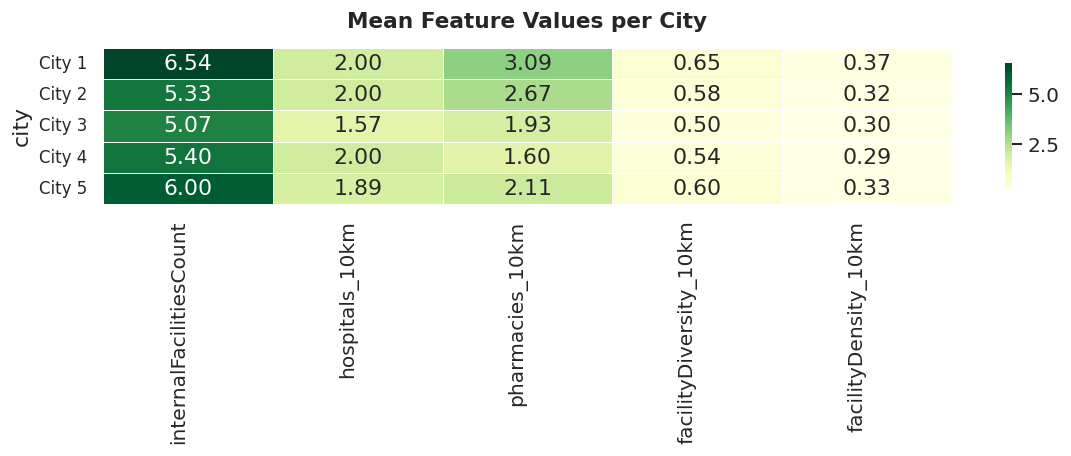

In [20]:
# --- City-Level Summary Statistics for Numeric Features ---

city_summary = (
    data.groupby("city")[numeric_features]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)
print("CITY-LEVEL FEATURE SUMMARY")
display(city_summary)

# Heat-mapped mean values for quick visual scanning
city_means = data.groupby("city")[numeric_features].mean().round(3)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    city_means,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title(
    "Mean Feature Values per City",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

plt.subplots_adjust(left=0.25)
plt.tight_layout()
plt.savefig("eda_visuals/eda_city_mean_heatmap.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATION

- City 1 is the highest-performing city across all five features: It has the highest internal facility count (6.54), most pharmacies (3.09), highest diversity (0.65), and highest density (0.37). This means City 1 centers are most likely to fall in the Premium cluster

- City 3 is the lowest performer overall: Despite having the most centers (14), it has the lowest internal count (5.07), fewest hospitals (1.57), fewest pharmacies (1.93), and lowest diversity (0.50). Its centers are most likely to fall in the Basic cluster

- Hospital access is remarkably uniform: All cities average between 1.57 and 2.00 hospitals, meaning this feature alone is not a strong city-level differentiator

- Pharmacy access shows the most city-level variation: City 1 (3.09) vs City 4 (1.60) is nearly double, making pharmacies a stronger geographic signal than hospitals

- Density and diversity move together: Across all cities, the ranking order is identical (City 1 > City 2/5 > City 3/4), confirming their correlation before even looking at the heatmap

- No single city has all low values: Even City 3's density (0.30) is moderate, suggesting no city is entirely in the Basic tier; quality is spread across the geography

#### EDA SUMMARY

- Dataset is clean: Zero missing values, all types correct, all range valid. No preprocessing needed beyond scaling
- 50 centers across 5 cities
- All 5 features are positively correlated (0.80 t0 0.90)
- Three natural groupings exist based on diversity vs density scatter plot and histogram bimodality
- City 1 has the highest quality on average: Expected to contribute more Premium centers
- City 3 has the lowest average quality: Expected to contribute more basic centers
- City is not a quality determinant: Based on the boxplots and pair plot, so it should not be a clustering feature
- Internal count is the anchor feature: r=0.90 with both diversity and density, it should the primary driver of premium vs basic separation
- Density and diversity have identical correlations
- Some right skew in density: Standard scalar will normalise this before clustering



## Feature Selection

In [21]:
# Columns that are identifiers or non-informative for quality classification

DROP_COLS = [
    "researchCenterId",    # unique string ID: no predictive value
    "researchCenterName",  # unique string label: no predictive value
    "city",                # categorical: EDA showed quality is not city-driven
    "latitude",            # geographic coordinate: not a quality signal
    "longitude",           # geographic coordinate: not a quality signal
]


# All remaining numeric columns are our candidate features
CANDIDATE_FEATURES = [col for col in data.columns if col not in DROP_COLS]

print("Candidate features for selection:")
for f in CANDIDATE_FEATURES:
    print(f"  → {f}")

Candidate features for selection:
  → internalFacilitiesCount
  → hospitals_10km
  → pharmacies_10km
  → facilityDiversity_10km
  → facilityDensity_10km


In [22]:
# --- Variance Analysis of Candidate Features (unscaled) ---

print("RAW VARIANCE: candidate features (unscaled)")
variance_report = pd.DataFrame({
    "feature":   CANDIDATE_FEATURES,
    "variance":  [data[f].var() for f in CANDIDATE_FEATURES],
    "std":       [data[f].std() for f in CANDIDATE_FEATURES],
    "mean":      [data[f].mean() for f in CANDIDATE_FEATURES],
    "cv_%":      [
        round((data[f].std() / data[f].mean()) * 100, 1)
        for f in CANDIDATE_FEATURES
    ],  # Coefficient of Variation = std/mean × 100
}).sort_values("variance", ascending=False).reset_index(drop=True)

display(variance_report)

RAW VARIANCE: candidate features (unscaled)


,feature,variance,std,mean,cv_%
0,internalFacilitiesCount,9.902449,3.146816,5.660000,55.6
1,pharmacies_10km,2.839184,1.684988,2.240000,75.2
2,hospitals_10km,1.796327,1.340271,1.860000,72.1
3,facilityDiversity_10km,0.062256,0.249511,0.568843,43.9
4,facilityDensity_10km,0.033329,0.182562,0.321164,56.8


In [23]:
# VarianceThreshold will automatically remove features with variance below the specified threshold.

print("VARIANCE THRESHOLD CHECK (threshold = 0.01)")

selector = VarianceThreshold(threshold=0.01)
selector.fit(data[CANDIDATE_FEATURES])
retained = [
    f for f, keep in zip(CANDIDATE_FEATURES, selector.get_support()) if keep
]
removed  = [
    f for f, keep in zip(CANDIDATE_FEATURES, selector.get_support()) if not keep
]

print(f"  Features retained : {retained}")
print(f"  Features removed  : {removed if removed else 'None - all pass threshold'}")

VARIANCE THRESHOLD CHECK (threshold = 0.01)
  Features retained : ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km']
  Features removed  : None - all pass threshold


##### KEY OBSERVATION

VarianceThreshold(threshold=0.01) removes any feature where variance < 0.01. The lowest raw variance in our dataset is facilityDensity_10km at 0.033 — more than 3× above the threshold.

All five features pass comfortably. This formally confirms:

- No feature is near-constant
- No feature would be useless to K-Means
- We do not need to remove anything on variance grounds alone

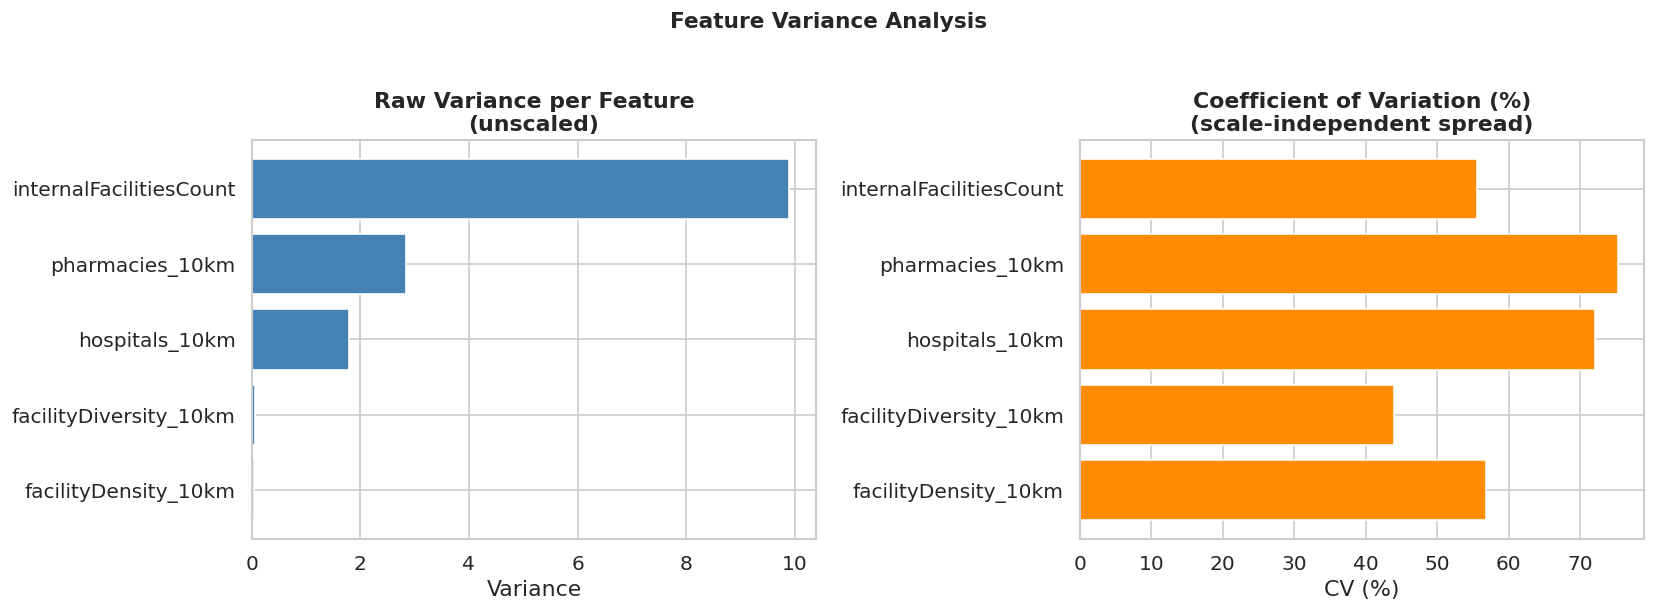

In [24]:
#--- Visual Comparison of Raw Variance and Coefficient of Variation ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw variance bar chart
axes[0].barh(
    variance_report["feature"],
    variance_report["variance"],
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("Raw Variance per Feature\n(unscaled)", fontweight="bold")
axes[0].set_xlabel("Variance")
axes[0].invert_yaxis()

# Coefficient of Variation bar chart
axes[1].barh(
    variance_report["feature"],
    variance_report["cv_%"],
    color="darkorange",
    edgecolor="white"
)
axes[1].set_title("Coefficient of Variation (%)\n(scale-independent spread)", 
                   fontweight="bold")
axes[1].set_xlabel("CV (%)")
axes[1].invert_yaxis()

plt.suptitle(
    "Feature Variance Analysis",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("features_visuals/feature_selection_variance.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATION

- Looking at the Raw variance per feature alone, one might conclude that diversity and density are almost irrelevant, that they bearly register as bars. This is completely wrong, it is a measurement scale illusion. This is precisely why we calculate the Coefficient of Variation

- CV removes the scale effects by expressing standard deviation as a percentage of the mean. A CV of 50% means the typical speed around the mean is half the size of the mean itself, which is substantial variation regardless of the actal units. 

This is the key insight from the variance analysis:

- pharmacies_10km (CV 75.2%) is actually the most relatively variable feature, centers differ more in pharmacy access than in anything else when scale is removed
- hospitals_10km (CV 72.1%) is second, also highly variable relative to its mean
- facilityDensity_10km (CV 56.8%) and internalFacilitiesCount (CV 55.6%) are very similar in relative spread, despite their raw variances differing by a factor of 300
- facilityDiversity_10km (CV 43.9%) has the lowest relative variation, but 43.9% is still a strong discriminative signal; this is not a near-constant feature

In [25]:
# --- Correlation Analysis of Candidate Features (Pearson) ---

corr_matrix = data[CANDIDATE_FEATURES].corr(method="pearson")

# Extracting all unique pairwise correlations (lower triangle only)
print("PAIRWISE CORRELATIONS: Ranked by absolute value")

pairs = []
for i in range(len(CANDIDATE_FEATURES)):
    for j in range(i + 1, len(CANDIDATE_FEATURES)):
        f1  = CANDIDATE_FEATURES[i]
        f2  = CANDIDATE_FEATURES[j]
        r   = corr_matrix.loc[f1, f2]
        pairs.append({"feature_1": f1, "feature_2": f2, "pearson_r": round(r, 3)})

corr_pairs = (
    pd.DataFrame(pairs)
    .sort_values("pearson_r", ascending=False)
    .reset_index(drop=True)
)
display(corr_pairs)

PAIRWISE CORRELATIONS: Ranked by absolute value


,feature_1,feature_2,pearson_r
0,internalFacilitiesCount,facilityDiversity_10km,0.904
1,internalFacilitiesCount,facilityDensity_10km,0.901
2,internalFacilitiesCount,pharmacies_10km,0.889
3,internalFacilitiesCount,hospitals_10km,0.879
4,facilityDiversity_10km,facilityDensity_10km,0.869
5,hospitals_10km,facilityDensity_10km,0.869
6,hospitals_10km,facilityDiversity_10km,0.853
7,pharmacies_10km,facilityDiversity_10km,0.834
8,pharmacies_10km,facilityDensity_10km,0.832
9,hospitals_10km,pharmacies_10km,0.801


##### KEY OBSERVATION

internalFacilitiesCount is the central hub feature

It sits at the top of every pairing that involves it:

- r = 0.904 with facilityDiversity_10km
- r = 0.901 with facilityDensity_10km
- r = 0.889 with pharmacies_10km
- r = 0.879 with hospitals_10km

This tells us that internalFacilitiesCount is the single strongest predictor of every other quality dimension. A research center that invests heavily in internal infrastructure consistently exists in a richer external environment. This is not coincidence, it reflects a real-world pattern where well-funded centers are built in well-served locations.

Why is this not a redundancy problem?

Because internalFacilitiesCount measures the center itself while all other features measure the surrounding area. A correlation of 0.90 means they are strongly related, but the remaining 19% unexplained variance represents real-world cases where:

- A center has many internal facilities but is in a poorly served area (high internal, low external)
- A center has few internal facilities but is in a medically rich area (low internal, high external)

These edge cases are clinically important and would be lost if we dropped any feature.

facilityDiversity_10km ↔ facilityDensity_10km = 0.869

The fourth-highest correlation in the entire table. These two external features are the closest to being redundant with each other, but:

- Density = how many total facilities are nearby (volume measure)
- Diversity = how many different types of facilities are nearby (variety measure)

An area with 50 pharmacies and nothing else would score high on density but low on diversity. An area with one hospital, one pharmacy, one clinic, and one diagnostic lab would score moderate on density but high on diversity.

The correlation of 0.869 means most areas that are dense are also diverse (and vice versa), but the 13% unexplained variance captures those real distinctions. Both are retained because they measure different aspects of the same environment.

hospitals_10km ↔ pharmacies_10km = 0.801

The lowest correlation in the entire table. This is actually the most interesting pair:

These are both external healthcare count features, yet they only share 64% of their variance (r² = 0.801² ≈ 0.64). This means 36% of variation in pharmacy count cannot be predicted from hospital count. A location can have many hospitals but few pharmacies (a specialist medical district) or many pharmacies but few hospitals (a residential high street). This is substantial independent information, both features must be retained.

The critical threshold: No correlation exceeds 0.95

The standard threshold for problematic redundancy in feature selection is r > 0.95 (some practitioners use 0.90). Our highest correlation is 0.904, just barely above 0.90 but still below 0.95.

At r = 0.904:

Shared variance = 0.904² ≈ 81.7%
Unique variance = 18.3%

That 18.3% represents real, independent information. Dropping either feature would lose it. Given we are working with only 50 data points and 3 desired clusters, retaining all five features, each contributing unique variance, produces more stable cluster assignments.

In [26]:
# --- Redundancy Decision Table ---

print("REDUNDANCY DECISION: feature-by-feature justification")

decisions = {
    "internalFacilitiesCount": {
        "max_r_with":  "facilityDiversity_10km / facilityDensity_10km (r=0.90)",
        "decision":    "RETAIN",
        "reason":      "Anchor feature, measures center's own capacity directly. "
                       "High r means it is a strong signal, not that it is redundant. "
                       "Cannot be replaced by any external metric."
    },
    "hospitals_10km": {
        "max_r_with":  "internalFacilitiesCount (r=0.88)",
        "decision":    "RETAIN",
        "reason":      "Measures a distinct dimension: proximity to acute medical care. "
                       "r=0.88 is high but the two features are not the same thing. "
                       "a center can have many labs but poor hospital access."
    },
    "pharmacies_10km": {
        "max_r_with":  "internalFacilitiesCount (r=0.89)",
        "decision":    "RETAIN",
        "reason":      "Captures medication/supply access, different from hospital care. "
                       "r with hospitals is 0.80 (not 0.90+), confirming it adds "
                       "independent variation beyond just replicating hospital count."
    },
    "facilityDiversity_10km": {
        "max_r_with":  "internalFacilitiesCount (r=0.90), density (r=0.87)",
        "decision":    "RETAIN",
        "reason":      "Measures how varied (not just numerous) nearby facilities are. "
                       "r=0.87 with density confirms they are related but not identical. "
                       "a high-density single-type area would score differently."
    },
    "facilityDensity_10km": {
        "max_r_with":  "internalFacilitiesCount (r=0.90), diversity (r=0.87)",
        "decision":    "RETAIN",
        "reason":      "Measures spatial concentration of all facilities nearby. "
                       "Complements diversity: density = how many, diversity = what types."
    },
}

for feat, info in decisions.items():
    print(f"\n  Feature  : {feat}")
    print(f"  Max corr : {info['max_r_with']}")
    print(f"  Decision : {info['decision']}")
    print(f"  Reason   : {info['reason']}")

REDUNDANCY DECISION: feature-by-feature justification

  Feature  : internalFacilitiesCount
  Max corr : facilityDiversity_10km / facilityDensity_10km (r=0.90)
  Decision : RETAIN
  Reason   : Anchor feature, measures center's own capacity directly. High r means it is a strong signal, not that it is redundant. Cannot be replaced by any external metric.

  Feature  : hospitals_10km
  Max corr : internalFacilitiesCount (r=0.88)
  Decision : RETAIN
  Reason   : Measures a distinct dimension: proximity to acute medical care. r=0.88 is high but the two features are not the same thing. a center can have many labs but poor hospital access.

  Feature  : pharmacies_10km
  Max corr : internalFacilitiesCount (r=0.89)
  Decision : RETAIN
  Reason   : Captures medication/supply access, different from hospital care. r with hospitals is 0.80 (not 0.90+), confirming it adds independent variation beyond just replicating hospital count.

  Feature  : facilityDiversity_10km
  Max corr : internalFaciliti

In [27]:
# Scale first: PCA requires standardised data

scaler_pca  = StandardScaler()
X_scaled    = scaler_pca.fit_transform(data[CANDIDATE_FEATURES])

pca_full    = PCA(n_components=len(CANDIDATE_FEATURES))
pca_full.fit(X_scaled)

explained_variance      = pca_full.explained_variance_ratio_
cumulative_variance     = np.cumsum(explained_variance)

pca_report = pd.DataFrame({
    "principal_component": [f"PC{i+1}" for i in range(len(CANDIDATE_FEATURES))],
    "explained_var_%":     (explained_variance * 100).round(2),
    "cumulative_var_%":    (cumulative_variance * 100).round(2),
})

print("PCA: VARIANCE EXPLAINED PER COMPONENT")
display(pca_report)

PCA: VARIANCE EXPLAINED PER COMPONENT


,principal_component,explained_var_%,cumulative_var_%
0,PC1,89.07,89.07
1,PC2,4.14,93.21
2,PC3,2.81,96.02
3,PC4,2.50,98.52
4,PC5,1.48,100.00


##### KEY OBSERVATION

PC1 captures 89.07% of all variance across all five features. This is a profoundly important finding.

What does it mean?

- There is essentially one dominant underlying dimension in this dataset
- That dimension is research center quality: a composite signal that all five features contribute to simultaneously
- When a center scores high on internal facilities, it almost always also scores high on hospitals, pharmacies, diversity, and density
- When it scores low on one, it tends to score low on all
- This validates the entire EDA observation that all correlations were 0.80–0.90: the data is telling a single coherent story about quality.

PC1 alone almost reaches the 90% threshold, meaning a single dimension explains nearly all the information in five features
PC2 adds only 4.14%, a small but non-trivial secondary dimension
PC3, PC4, PC5 each add less than 3%, they represent fine-grained residual variation
Why not use PCA-transformed features for clustering then?

Despite PC1 explaining 89%, we deliberately keep the original five features because:

1. After clustering, we need to describe Premium centers as having "average 9.2 internal facilities", not "average PC1 score of 2.31"
2. The API endpoint would receives real feature values, not PCA coordinates
3. With 50 data points and K=3 clusters, the added complexity of PCA transformation is not justified
4. The original features are already well-behaved after StandardScaler


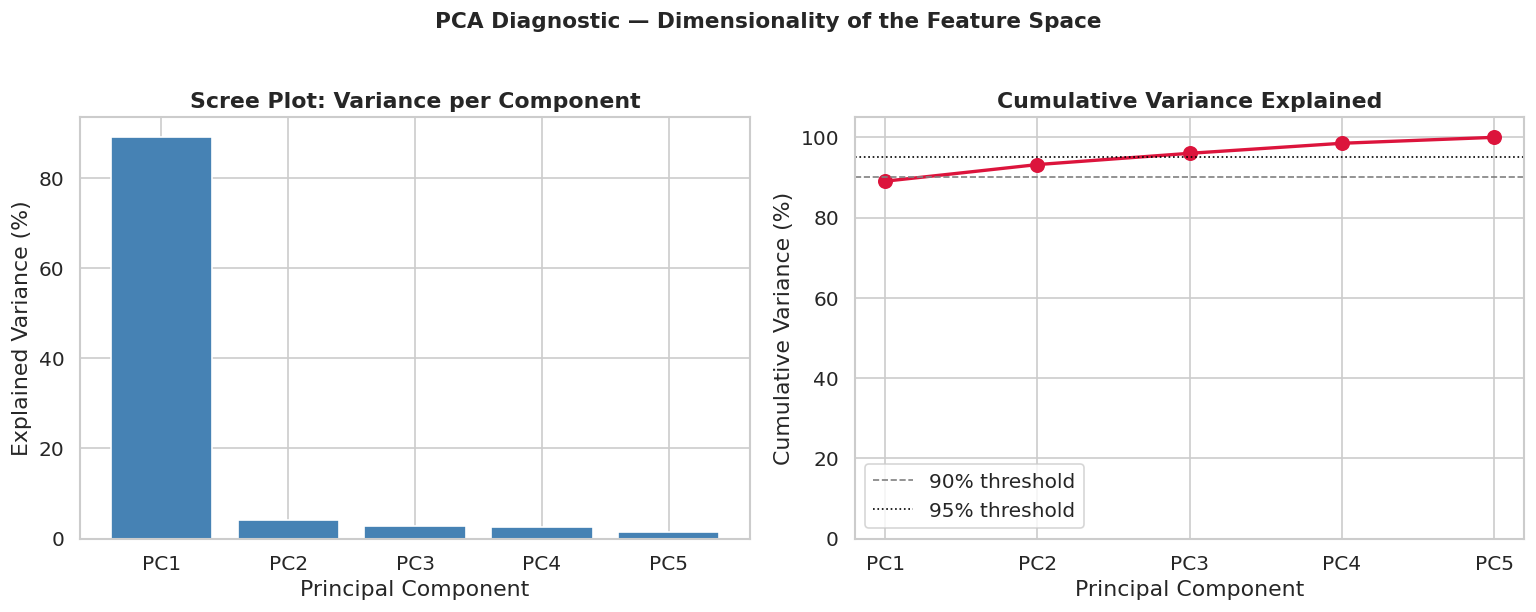

In [28]:
# Determine how many components are needed to reach 90% and 95% cumulative variance

# Visualise scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(
    pca_report["principal_component"],
    pca_report["explained_var_%"],
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("Scree Plot: Variance per Component",
                   fontweight="bold")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_xlabel("Principal Component")

# Cumulative variance
axes[1].plot(
    pca_report["principal_component"],
    pca_report["cumulative_var_%"],
    marker="o",
    color="crimson",
    linewidth=2,
    markersize=8,
)
axes[1].axhline(90, color="grey",  linestyle="--", linewidth=1, label="90% threshold")
axes[1].axhline(95, color="black", linestyle=":", linewidth=1, label="95% threshold")
axes[1].set_title("Cumulative Variance Explained", fontweight="bold")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_xlabel("Principal Component")
axes[1].legend()
axes[1].set_ylim([0, 105])

plt.suptitle(
    "PCA Diagnostic — Dimensionality of the Feature Space",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("features_visuals/feature_selection_pca_scree.png", bbox_inches="tight")
plt.show()

In [29]:
# PCA loadings: Which original features drive each component?

print("PCA LOADINGS: Contribution of each feature to each component")

loadings = pd.DataFrame(
    pca_full.components_.T,
    index=CANDIDATE_FEATURES,
    columns=[f"PC{i+1}" for i in range(len(CANDIDATE_FEATURES))]
).round(3)

display(loadings)

PCA LOADINGS: Contribution of each feature to each component


,PC1,PC2,PC3,PC4,PC5
internalFacilitiesCount,0.459,0.105,0.068,0.009,0.879
hospitals_10km,0.442,-0.562,-0.527,-0.444,-0.119
pharmacies_10km,0.437,0.783,-0.308,-0.111,-0.297
facilityDiversity_10km,0.448,-0.090,0.788,-0.301,-0.282
facilityDensity_10km,0.449,-0.228,-0.038,0.837,-0.213


##### KEY OBSERVATION

A loading value tells us how strongly and in which direction each original feature contributes to a given principal component.

- Positive loading: Feature increases → component score increases
- Negative loading: Feature increases → component score decreases
- Loading close to 0: Feature barely contributes to this component
- Loading close to ±1: Feature strongly defines this component

PC1 Loadings: The Quality Axis

All five loadings are positive, and all are nearly identical (0.437–0.459).

This is the most important result in the entire feature selection analysis. It means:

- PC1 represents a perfectly balanced quality composite, every feature contributes almost equally
- Moving along PC1 means simultaneously increasing or decreasing on all five quality dimensions
- A high PC1 score = high internal facilities AND high hospitals AND high pharmacies AND high diversity AND high density = Premium center
- A low PC1 score = low on everything = Basic center

The near-equal loadings (no feature dominates at 0.7 or 0.8 while others sit at 0.1) confirm that no single feature is redundant or disproportionately influential, all five genuinely contribute to the primary quality dimension.

PC2 Loadings: The Pharmacy vs Hospital Contrast (4.14% of variance)

PC2 contrasts pharmacies against hospitals. A high PC2 score means a center has:

- Many nearby pharmacies
- But relatively few hospitals

A low PC2 score means the opposite, many hospitals, few pharmacies.

This secondary dimension represents a real geographic distinction:

- High-street / residential areas: Many pharmacies serving daily medication needs, fewer hospitals
- Medical district / specialist zones: Major hospitals but fewer retail pharmacies

This is subtle but genuinely useful, it explains why hospitals_10km ↔ pharmacies_10km had the lowest correlation (0.801) of any pair. They diverge on this secondary dimension.

The bar chart below clearly shows this pattern:

- pharmacies_10km orange bar shoots up to +0.78
- hospitals_10km orange bar drops to -0.56
- All others sit near zero on PC2

PC3 Loadings: Diversity vs Hospitals (2.81% of variance)

PC3 contrasts facility diversity against hospital count. A high PC3 score means:

- High variety of facility types nearby
- But relatively fewer hospitals

This captures areas where healthcare is diverse but not dominated by hospital infrastructure, for example, a location with clinics, pharmacies, diagnostics labs, and GP surgeries but no major hospital within 10 km.

PC4 Loadings: Density vs Hospitals (2.50% of variance)

PC4 contrasts density against hospitals specifically. Dense areas with fewer hospitals, perhaps high-density urban areas with many small clinics and pharmacies but no major hospital campus nearby.

PC5 Loadings: Pure Internal Count (1.48% of variance)

PC5 is almost entirely driven by internalFacilitiesCount. It captures the small amount of variance where a center's internal capacity is unusually high or low relative to its external environment, the edge cases where internal and external quality diverge.

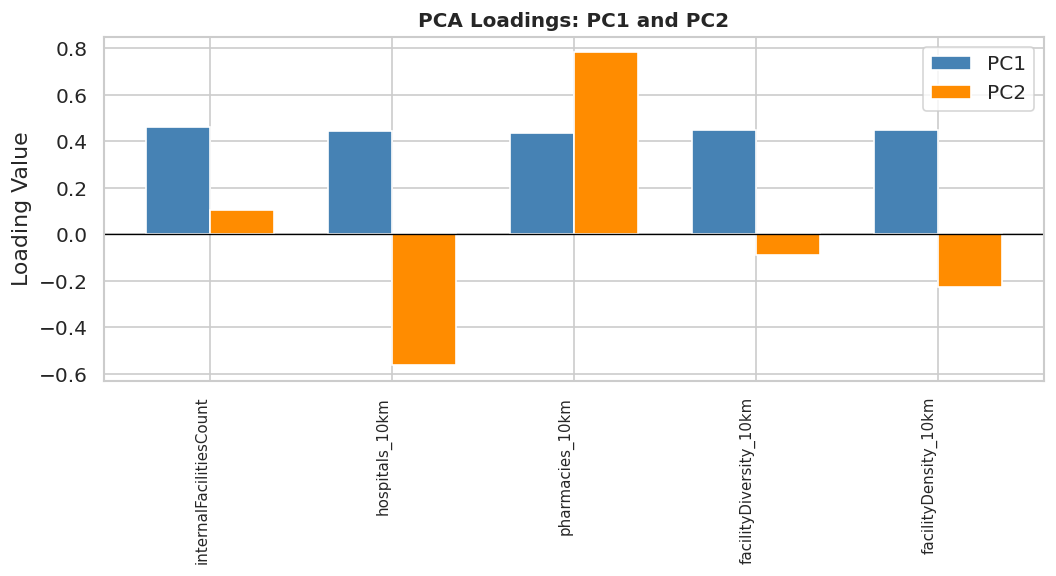

In [30]:
# Visualise PC1 and PC2 loadings
fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(CANDIDATE_FEATURES))
width  = 0.35

bars1 = ax.bar(x - width/2, loadings["PC1"], width,
               label="PC1", color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, loadings["PC2"], width,
               label="PC2", color="darkorange", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(CANDIDATE_FEATURES, rotation=90, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Loading Value")
ax.set_title("PCA Loadings: PC1 and PC2", fontsize=12, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("features_visuals/feature_selection_pca_loadings.png", bbox_inches="tight")
plt.show()

In [31]:
SELECTED_FEATURES = [
    "internalFacilitiesCount",   # primary internal quality signal
    "hospitals_10km",            # external acute care access
    "pharmacies_10km",           # external medication/supply access
    "facilityDiversity_10km",    # variety of nearby healthcare types
    "facilityDensity_10km",      # spatial concentration of nearby facilities
]

X = data[SELECTED_FEATURES].copy()

# Fit and transform
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=SELECTED_FEATURES)

print("SCALED FEATURE SUMMARY — post StandardScaler")
print("  Expected: mean ≈ 0.0, std ≈ 1.0 for every column")

display(X_scaled_df.describe().round(4).T)

SCALED FEATURE SUMMARY — post StandardScaler
  Expected: mean ≈ 0.0, std ≈ 1.0 for every column


,count,mean,std,min,25%,50%,75%,max
internalFacilitiesCount,50.0,-0.0,1.0102,-1.4959,-0.8539,-0.2119,0.9919,1.7142
hospitals_10km,50.0,-0.0,1.0102,-1.4019,-0.6482,0.1055,0.8592,1.6129
pharmacies_10km,50.0,-0.0,1.0102,-1.3429,-0.7434,-0.1439,0.4556,1.6546
facilityDiversity_10km,50.0,0.0,1.0102,-1.8191,-0.9097,0.0675,0.9378,1.7172
facilityDensity_10km,50.0,0.0,1.0102,-1.4642,-0.8153,-0.1305,0.8589,2.0797


##### KEY OBSERVATION

fore each feature, every value is transformed using: z = (x - mean) / standard_deviation

This produces a z-score, the number of standard deviations a value sits above or below the mean.

Verifying the scaling worked correctly

Mean ≈ 0.0 for all features

- Every feature is now centred at zero
- A z-score of 0 means "exactly average"
- Before scaling: means were 5.66, 1.86, 2.24, 0.57, 0.32, wildly different
- After scaling: all means are 0.0, perfectly aligned

Std ≈ 1.0102 for all features

- Every feature now has unit variance
- The slight deviation from exactly 1.0 (we see 1.0102) is because sklearn uses the biased standard deviation formula by default with n in the denominator rather than n-1
- This is a known and intentional behaviour, the effect is negligible at n=50

What does z-score ranges mean?

internalFacilitiesCount: min = -1.496, max = 1.714

- The most basic center (1 facility) sits 1.496 standard deviations below the mean
- The most equipped center (11 facilities) sits 1.714 standard deviations above the mean
- A center with exactly 5.66 facilities would score 0.0

facilityDensity_10km: max = 2.0797 (the highest maximum)

- The densest center is 2.08 standard deviations above the mean, making it a mild outlier
- This reflects the right skew we observed in the histogram, a few high-density centers pull into the upper tail
- After scaling, this becomes z = 2.08 rather than the original value of 0.697, but it is still proportionally the most extreme value in the dataset
- K-Means implication: This center will be a strong pull toward the Premium cluster centroid on the density dimension

facilityDiversity_10km: min = -1.819 (the most extreme minimum)

- The least diverse center sits 1.82 standard deviations below average
- This is a stronger pull toward the Basic cluster than any other feature's minimum
- Reflects the original value of 0.12, well below the mean of 0.57

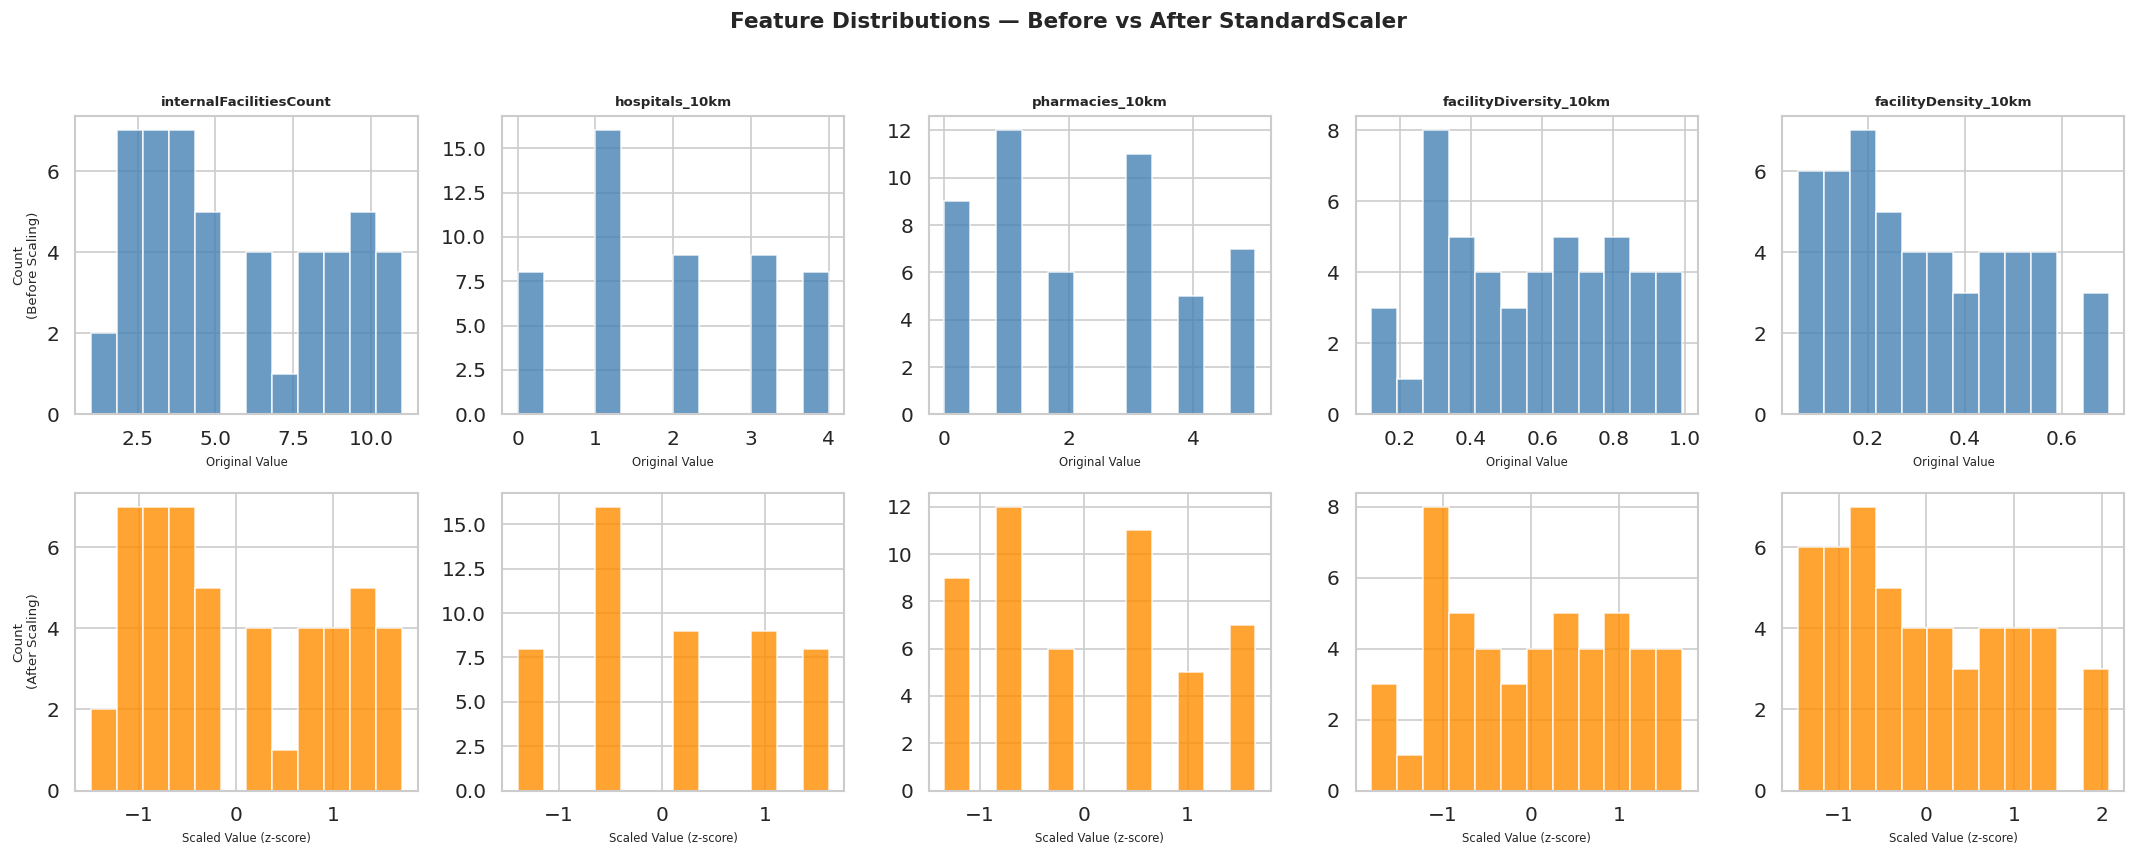

In [32]:
# Visualise pre vs post scaling distributions side by side
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, col in enumerate(SELECTED_FEATURES):
    # Pre-scaling
    axes[0, i].hist(X[col], bins=12, color="steelblue",
                    edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col, fontsize=8, fontweight="bold")
    axes[0, i].set_xlabel("Original Value", fontsize=7)
    if i == 0:
        axes[0, i].set_ylabel("Count\n(Before Scaling)", fontsize=8)

    # Post-scaling
    axes[1, i].hist(X_scaled_df[col], bins=12, color="darkorange",
                    edgecolor="white", alpha=0.8)
    axes[1, i].set_xlabel("Scaled Value (z-score)", fontsize=7)
    if i == 0:
        axes[1, i].set_ylabel("Count\n(After Scaling)", fontsize=8)

fig.suptitle(
    "Feature Distributions — Before vs After StandardScaler",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("features_visuals/feature_selection_scaling_comparison.png", bbox_inches="tight")
plt.show()

##### KEY OBSERVATION

Before vs After Scaling: Visual Analysis as seen above
The histogram grid confirms everything numerically:

Top row (Before Scaling: Blue):

- internalFacilitiesCount: bars span roughly 1–11, centred around 5
- hospitals_10km: bars span 0–4, peaked at 1
- pharmacies_10km: bars span 0–5, peaked at 1 and again at 3
- facilityDiversity_10km: bars span 0.2–1.0
- facilityDensity_10km: bars span 0.1–0.7, right-skewed

Bottom row (After Scaling: Orange):

All five distributions are now on the same x-axis scale (roughly -2 to +2)
The shapes are identical to the blue row, StandardScaler does not change shape, only position and scale
All bars now overlap on the same axis, visually confirming equal contribution to distance

The most important visual confirmation:

Before scaling, internalFacilitiesCount had bars reaching x=10 while facilityDensity_10km had bars only reaching x=0.7. K-Means would have treated a 10-unit difference in facility count as equivalent to a 14-unit difference in density, even though 0.7 is the maximum possible density value. After scaling, both features occupy the same -2 to +2 range, and K-Means treats them with equal weight.

## K-Means Clustering Model

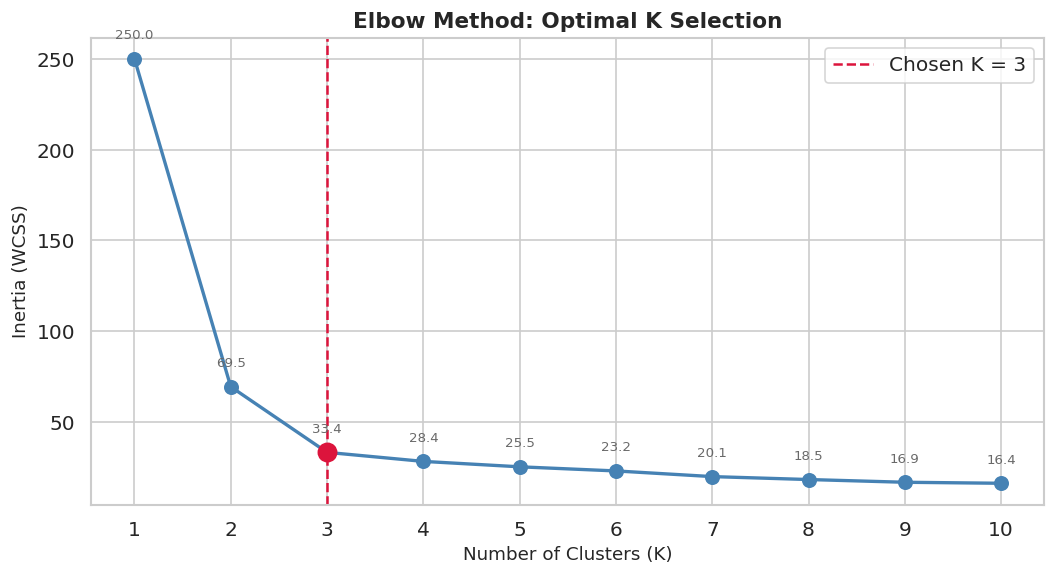

INERTIA TABLE: Drop in WCSS per additional K


,K,Inertia,Drop_from_prev
0,1,250.00,NaN
1,2,69.51,180.49
2,3,33.40,36.11
3,4,28.43,4.98
4,5,25.45,2.98
5,6,23.18,2.27
6,7,20.06,3.12
7,8,18.45,1.61
8,9,16.95,1.51
9,10,16.39,0.55


In [33]:
# Determine the optimal number of clusters using the elbow method

# Test K from 1 to 10 (beyond 10 is unlikely to be meaningful given our dataset size and context)
K_RANGE    = range(1, 11)
inertias   = []
random_state = 42

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=random_state
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)

"""
K-Means Clustering and Parameter Choices

Inertia (Within-Cluster Sum of Squares — WCSS):
    Inertia measures how tightly grouped the data points are within each cluster.
    For every data point, it computes the squared distance to its assigned cluster centroid.
    The total inertia is the sum of these squared distances across all data points.

    - Low inertia indicates that points are close to their centroids (well-clustered).
    - High inertia indicates that points are far from their centroids (poor clustering).

Why the Elbow Method Works:
    Increasing the number of clusters (K) will always reduce inertia because clusters
    become smaller and more specific. In the extreme case where K equals the number of
    data points, each point becomes its own cluster and inertia becomes zero.

    The goal is to find the "elbow point" — where the rate of decrease in inertia
    sharply slows down. This point represents a balance between model simplicity
    and clustering performance, suggesting the optimal number of clusters.

K-Means Parameters:

    init="k-means++":
        Uses a smart initialization technique that spreads initial centroids far apart.
        This improves convergence speed and reduces the likelihood of poor clustering results.

    n_init=10:
        Runs the K-Means algorithm 10 times with different centroid initializations
        and selects the best result based on the lowest inertia.
        This helps avoid suboptimal solutions due to random initialization.

    max_iter=300:
        Sets the maximum number of iterations for a single run.
        The algorithm stops early if convergence is reached before this limit.

    random_state=42:
        Ensures reproducibility by fixing the random number generator seed,
        so results remain consistent across runs.
"""

# Visualise the elbow curve
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    list(K_RANGE), inertias,
    marker="o", linewidth=2, color="steelblue", markersize=8
)

# Highlight K=3 — our chosen value
ax.axvline(x=3, color="crimson", linestyle="--",
           linewidth=1.5, label="Chosen K = 3")
ax.scatter([3], [inertias[2]], color="crimson", zorder=5, s=120)

ax.set_xlabel("Number of Clusters (K)", fontsize=11)
ax.set_ylabel("Inertia (WCSS)", fontsize=11)
ax.set_title(
    "Elbow Method: Optimal K Selection",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(list(K_RANGE))
ax.legend()

# Annotate inertia values at each K
for k, inertia in zip(K_RANGE, inertias):
    ax.annotate(
        f"{inertia:.1f}",
        xy=(k, inertia),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="dimgrey"
    )

plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_elbow.png", bbox_inches="tight")
plt.show()

# Print inertia table
inertia_df = pd.DataFrame({
    "K":              list(K_RANGE),
    "Inertia":        [round(i, 2) for i in inertias],
    "Drop_from_prev": [None] + [
        round(inertias[i-1] - inertias[i], 2)
        for i in range(1, len(inertias))
    ]
})
print("INERTIA TABLE: Drop in WCSS per additional K")

display(inertia_df)

  K= 2  →  Silhouette Score: 0.6034
  K= 3  →  Silhouette Score: 0.5519
  K= 4  →  Silhouette Score: 0.4423
  K= 5  →  Silhouette Score: 0.3357
  K= 6  →  Silhouette Score: 0.3339
  K= 7  →  Silhouette Score: 0.2469
  K= 8  →  Silhouette Score: 0.2499
  K= 9  →  Silhouette Score: 0.2647
  K=10  →  Silhouette Score: 0.2446


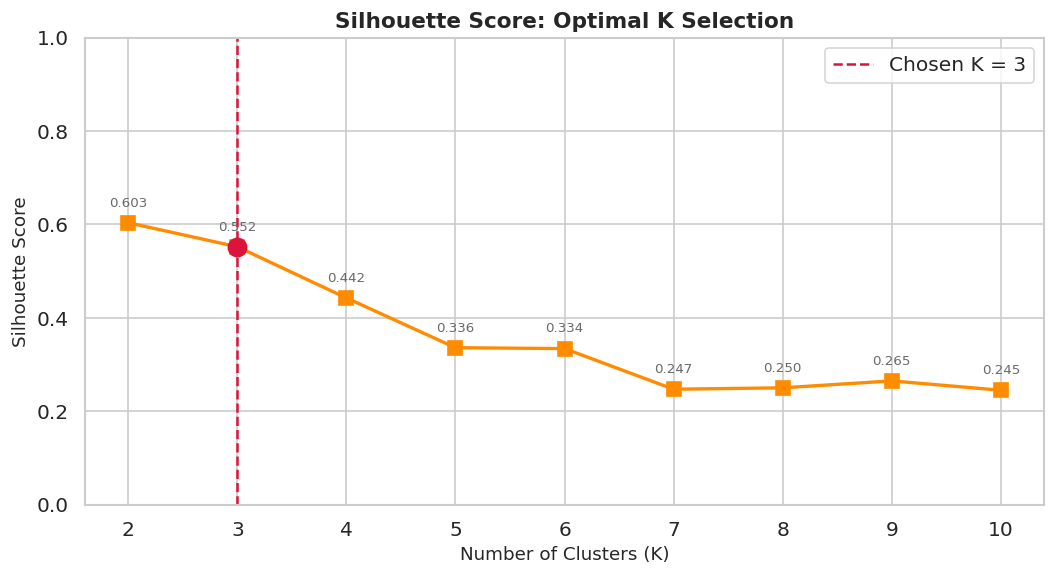

In [34]:
# Determine the optimal number of clusters using silhouette scores for K=2 to 10, since silhouette is not defined for K=1

K_RANGE_SIL  = range(2, 11)
sil_scores   = []

for k in K_RANGE_SIL:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=random_state
    )
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  K={k:2d}  →  Silhouette Score: {score:.4f}")

"""
Silhouette Score: Rationale and Interpretation

The silhouette score evaluates how well each data point fits within its assigned
cluster compared to other clusters.

For a given data point i, the silhouette score s(i) is defined as:

    s(i) = (b(i) - a(i)) / max(a(i), b(i))

Where:
    a(i):
        The average distance between point i and all other points in the same cluster.
        This measures cohesion (how tightly grouped the cluster is).
        Lower values indicate better cohesion.

    b(i):
        The average distance between point i and all points in the nearest neighboring cluster.
        This measures separation (how distinct the cluster is from others).
        Higher values indicate better separation.

Interpretation of s(i):
    +1.0:
        The point is well matched to its own cluster and clearly separated from others.

    0.0:
        The point lies near the boundary between two clusters.

    -1.0:
        The point is likely assigned to the wrong cluster.

Overall Silhouette Score:
    The final score is the average of s(i) across all data points.

    General guidelines:
        > 0.70:
            Strong, well-separated clusters

        0.50 – 0.70:
            Reasonable clustering structure

        0.25 – 0.50:
            Weak clustering, with noticeable overlap

        < 0.25:
            Poor clustering, no clear structure in the data
"""

# Visualise silhouette scores
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    list(K_RANGE_SIL), sil_scores,
    marker="s", linewidth=2, color="darkorange", markersize=8
)

# Highlight K=3
ax.axvline(x=3, color="crimson", linestyle="--",
           linewidth=1.5, label="Chosen K = 3")
ax.scatter(
    [3], [sil_scores[1]],   # index 1 = K=3 (K_RANGE_SIL starts at 2)
    color="crimson", zorder=5, s=120
)

ax.set_xlabel("Number of Clusters (K)", fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=11)
ax.set_title(
    "Silhouette Score: Optimal K Selection",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(list(K_RANGE_SIL))
ax.set_ylim([0, 1])
ax.legend()

# Annotate scores
for k, score in zip(K_RANGE_SIL, sil_scores):
    ax.annotate(
        f"{score:.3f}",
        xy=(k, score),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="dimgrey"
    )

plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_silhouette_k_selection.png", bbox_inches="tight")
plt.show()

Using BOTH elbow and silhouette methods is best practice:

Elbow alone can be ambiguous, the "bend" is sometimes gradual
Silhouette alone might favour a K that is statistically neat but does not align with business requirements (we need exactly 3 tiers)
When BOTH methods agree on K=3, we have strong quantitative justification for our choice, not just a business requirement.

In [35]:
# Final K-Means model with K=3 clusters

K_FINAL = 3

kmeans = KMeans(
    n_clusters  = K_FINAL,
    init        = "k-means++",
    n_init      = 50,          # increased from 10 for final model stability
    max_iter    = 300,
    tol         = 1e-4,        # convergence tolerance
    random_state= random_state,
    algorithm   = "lloyd"      # standard Lloyd's algorithm
)

kmeans.fit(X_scaled)

# Retrieve cluster labels (0, 1, or 2 for each of the 50 centers)
cluster_labels = kmeans.labels_

print("K-MEANS MODEL: TRAINING RESULTS")
print(f"  Number of clusters (K)   : {K_FINAL}")
print(f"  Final inertia (WCSS)     : {kmeans.inertia_:.4f}")
print(f"  Iterations to converge   : {kmeans.n_iter_}")
print(f"  Cluster label counts     : "
      f"{dict(zip(*np.unique(cluster_labels, return_counts=True)))}")

"""
Final K-Means Model: Rationale for Parameter Choices

n_init=50:
    During experimentation (elbow method and silhouette analysis), n_init=10
    was used to balance speed and performance. For the final model, n_init is
    increased to 50 to improve robustness.

    This means the algorithm runs 50 times with different centroid initializations
    and selects the best result based on the lowest inertia. Increasing n_init
    reduces the risk of converging to a poor local minimum and ensures a more
    stable and reliable final clustering outcome.

tol=1e-4:
    This parameter controls the convergence threshold. The algorithm stops when
    the movement of cluster centroids between iterations is less than 0.0001.

    Although this is the default value, it is explicitly defined here for clarity
    and transparency in the model configuration.

algorithm="lloyd":
    Specifies the classic K-Means algorithm.

    The Lloyd algorithm works by:
        1. Assigning each data point to the nearest centroid
        2. Recomputing centroids based on current cluster assignments
        3. Repeating until convergence

    While the "elkan" variant can be faster in some cases, "lloyd" is chosen
    because it is more stable for smaller datasets and is the standard,
    widely understood implementation.

random_state=42:
    Fixes the random seed to ensure reproducibility.

    This guarantees that every run of the model produces the same cluster
    assignments, making results consistent and easier to debug, validate,
    and compare.
"""

K-MEANS MODEL: TRAINING RESULTS
  Number of clusters (K)   : 3
  Final inertia (WCSS)     : 33.4022
  Iterations to converge   : 3
  Cluster label counts     : {np.int32(0): np.int64(17), np.int32(1): np.int64(17), np.int32(2): np.int64(16)}


'\nFinal K-Means Model: Rationale for Parameter Choices\n\nn_init=50:\n    During experimentation (elbow method and silhouette analysis), n_init=10\n    was used to balance speed and performance. For the final model, n_init is\n    increased to 50 to improve robustness.\n\n    This means the algorithm runs 50 times with different centroid initializations\n    and selects the best result based on the lowest inertia. Increasing n_init\n    reduces the risk of converging to a poor local minimum and ensures a more\n    stable and reliable final clustering outcome.\n\ntol=1e-4:\n    This parameter controls the convergence threshold. The algorithm stops when\n    the movement of cluster centroids between iterations is less than 0.0001.\n\n    Although this is the default value, it is explicitly defined here for clarity\n    and transparency in the model configuration.\n\nalgorithm="lloyd":\n    Specifies the classic K-Means algorithm.\n\n    The Lloyd algorithm works by:\n        1. Assignin

In [36]:
# Overall silhouette score for the model with K=3 clusters

overall_sil = silhouette_score(X_scaled, cluster_labels)

print("EVALUATION: SILHOUETTE SCORE")
print(f"Overall Silhouette Score : {overall_sil:.4f}")

# Interpret the score
if overall_sil > 0.70:
    interpretation = "Strong clusters: well separated and dense"
elif overall_sil > 0.50:
    interpretation = "Reasonable clusters: moderate separation"
elif overall_sil > 0.25:
    interpretation = "Weak clusters: some overlap"
else:
    interpretation = "No meaningful cluster structure"

print(f"Interpretation           : {interpretation}")

EVALUATION: SILHOUETTE SCORE
Overall Silhouette Score : 0.5519
Interpretation           : Reasonable clusters: moderate separation


In [37]:
# Per-cluster silhouette scores
per_point_sil = silhouette_samples(X_scaled, cluster_labels)

sil_by_cluster = pd.DataFrame({
    "cluster":         cluster_labels,
    "silhouette":      per_point_sil
}).groupby("cluster")["silhouette"].agg(["mean", "min", "max", "std"]).round(4)

print("SILHOUETTE SCORE: PER CLUSTER BREAKDOWN")

display(sil_by_cluster)

SILHOUETTE SCORE: PER CLUSTER BREAKDOWN


,mean,min,max,std
cluster,,,,
0,0.4715,0.2162,0.5752,0.0982
1,0.5943,0.4894,0.6843,0.0651
2,0.5923,0.4925,0.6533,0.0481


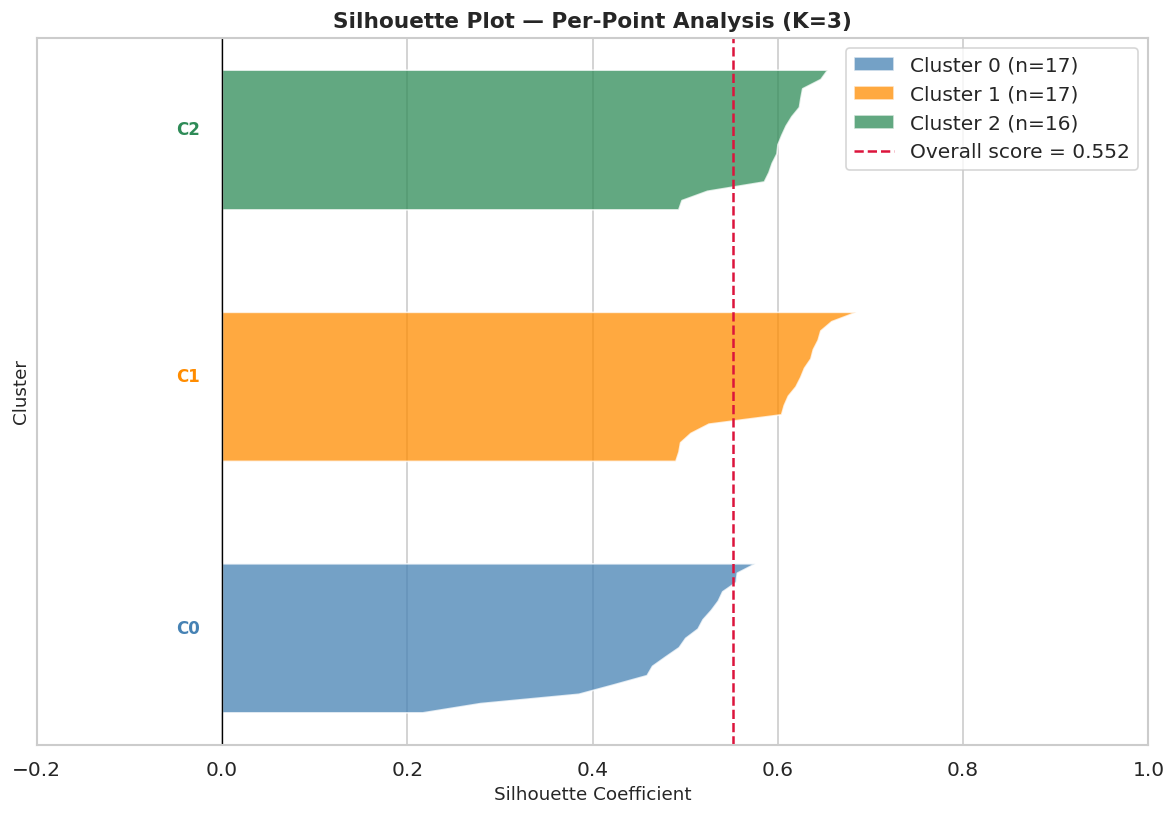

In [38]:
# Silhouette plot (per-point visualisation)
fig, ax = plt.subplots(figsize=(10, 7))

colours     = ["steelblue", "darkorange", "seagreen"]
y_lower     = 10

for cluster_id in range(K_FINAL):
    # Get silhouette values for this cluster, sorted
    cluster_sil_vals = np.sort(
        per_point_sil[cluster_labels == cluster_id]
    )
    cluster_size = len(cluster_sil_vals)
    y_upper = y_lower + cluster_size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_sil_vals,
        facecolor=colours[cluster_id],
        alpha=0.75,
        label=f"Cluster {cluster_id} (n={cluster_size})"
    )
    # Label the cluster in the middle of its band
    ax.text(
        -0.05,
        y_lower + cluster_size / 2,
        f"C{cluster_id}",
        fontsize=10,
        fontweight="bold",
        color=colours[cluster_id]
    )
    y_lower = y_upper + 10   # gap between clusters

# Vertical line at overall silhouette score
ax.axvline(
    x=overall_sil,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall score = {overall_sil:.3f}"
)
ax.axvline(x=0, color="black", linewidth=0.8)

ax.set_xlabel("Silhouette Coefficient", fontsize=11)
ax.set_ylabel("Cluster", fontsize=11)
ax.set_title(
    "Silhouette Plot — Per-Point Analysis (K=3)",
    fontsize=13, fontweight="bold"
)
ax.set_yticks([])
ax.set_xlim([-0.2, 1.0])
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_silhouette_plot.png", bbox_inches="tight")
plt.show()

The silhouette plot shows every single data point as a horizontal bar.
Bar width = silhouette score for that point.

What to look for:

- GOOD cluster: all bars extend well past the overall mean (red line), no negative bars, consistent width throughout
- BAD cluster:  many bars below or near zero, negative bars visible, uneven width (some points well-placed, others on boundary)

Negative silhouette score for a point means it is closer to a neighbouring cluster than its own cluster, it has been misassigned. 

In [39]:
# Cluster Centroid Analysis

centroids_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=SELECTED_FEATURES
).round(4)
centroids_scaled.index.name = "cluster"

print("CLUSTER CENTROIDS: scaled space (z-scores)")
print("  Positive = above average   |   Negative = below average")
display(centroids_scaled)

CLUSTER CENTROIDS: scaled space (z-scores)
  Positive = above average   |   Negative = below average


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
cluster,,,,,
0,-0.2307,-0.2492,-0.1086,-0.0361,-0.1733
1,1.2421,1.2139,1.1257,1.1400,1.1934
2,-1.0746,-1.0250,-1.0806,-1.1729,-1.0839


In [40]:
# Centroids in original (unscaled) space

centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=SELECTED_FEATURES
).round(3)
centroids_original.index.name = "cluster"

print("CLUSTER CENTROIDS: original scale (interpretable values)")
display(centroids_original)

"""
Cluster Centroid Interpretation: Scaled vs Original Space

It is important to examine cluster centroids in both scaled (standardized)
and original feature spaces, as each provides different insights.

Scaled Centroids (Z-scores):
    These indicate the relative position of each cluster compared to the dataset mean.

    - Positive values:
        The cluster is above average for that feature.

    - Negative values:
        The cluster is below average.

    Interpretation:
        • All positive z-scores → high-performing cluster → likely "Premium"
        • All negative z-scores → low-performing cluster → likely "Basic"
        • Mixed or near-zero values → moderate cluster → likely "Standard"

    This view helps understand the *direction* and relative strength of clusters.

Original-Scale Centroids:
    These represent actual feature values in their real units, making them
    directly interpretable by stakeholders.

    Example:
        "Premium centers average 9.4 internal facilities and 3.2 hospitals nearby"

    This is more actionable than abstract z-scores and supports decision-making.

Inverse Transformation:
    The scaler.inverse_transform() method converts standardized values
    back to their original scale using:

        original_value = (z_score × standard_deviation) + mean

    This allows seamless movement between analytical (scaled) and
    business-facing (original) interpretations.
"""

CLUSTER CENTROIDS: original scale (interpretable values)


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
cluster,,,,,
0,4.941,1.529,2.059,0.560,0.290
1,9.529,3.471,4.118,0.850,0.537
2,2.312,0.500,0.438,0.279,0.125


'\nCluster Centroid Interpretation: Scaled vs Original Space\n\nIt is important to examine cluster centroids in both scaled (standardized)\nand original feature spaces, as each provides different insights.\n\nScaled Centroids (Z-scores):\n    These indicate the relative position of each cluster compared to the dataset mean.\n\n    - Positive values:\n        The cluster is above average for that feature.\n\n    - Negative values:\n        The cluster is below average.\n\n    Interpretation:\n        • All positive z-scores → high-performing cluster → likely "Premium"\n        • All negative z-scores → low-performing cluster → likely "Basic"\n        • Mixed or near-zero values → moderate cluster → likely "Standard"\n\n    This view helps understand the *direction* and relative strength of clusters.\n\nOriginal-Scale Centroids:\n    These represent actual feature values in their real units, making them\n    directly interpretable by stakeholders.\n\n    Example:\n        "Premium center

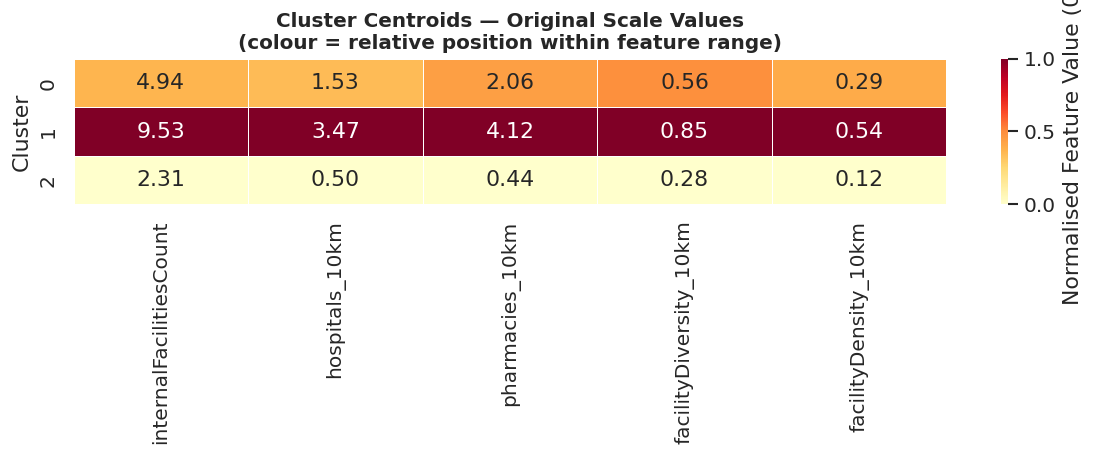

In [41]:
# Heatmap of original-scale centroids

fig, ax = plt.subplots(figsize=(10, 4))

# Normalise each column to 0-1 for colour scaling
centroid_norm = (centroids_original - centroids_original.min()) / \
                (centroids_original.max() - centroids_original.min())

sns.heatmap(
    centroid_norm,
    annot=centroids_original,   # show original values as annotations
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Normalised Feature Value (0–1)"}
)
ax.set_title(
    "Cluster Centroids — Original Scale Values\n"
    "(colour = relative position within feature range)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_centroid_heatmap.png", bbox_inches="tight")
plt.show()

The dual annotation approach (actual values + colour gradient) allows:
- Business stakeholders → read exact centroid values
- Technical reviewers   → see relative cluster separation via colour

Darker cells = higher values = better-resourced cluster on that feature

In [42]:
# Map Cluster Numbers to Quality Tier Labels

# Determine which cluster number corresponds to which tier by ranking clusters on their mean internalFacilitiesCount

cluster_means = centroids_original["internalFacilitiesCount"]
ranked        = cluster_means.sort_values(ascending=False)

print("CLUSTER RANKING: by internalFacilitiesCount centroid")
for rank, (cluster_id, mean_val) in enumerate(ranked.items()):
    print(f"  Rank {rank+1}: Cluster {cluster_id}  "
          f"→ mean internalFacilitiesCount = {mean_val:.2f}")

CLUSTER RANKING: by internalFacilitiesCount centroid
  Rank 1: Cluster 1  → mean internalFacilitiesCount = 9.53
  Rank 2: Cluster 0  → mean internalFacilitiesCount = 4.94
  Rank 3: Cluster 2  → mean internalFacilitiesCount = 2.31


In [43]:
# Build the mapping: highest count = Premium, middle = Standard, lowest = Basic
CLUSTER_TO_TIER = {
    int(ranked.index[0]): "Premium",    # highest internal facilities
    int(ranked.index[1]): "Standard",   # middle
    int(ranked.index[2]): "Basic",      # lowest internal facilities
}

print("CLUSTER → TIER MAPPING")
for cluster_id, tier in CLUSTER_TO_TIER.items():
    print(f"  Cluster {cluster_id}  →  {tier}")

CLUSTER → TIER MAPPING
  Cluster 1  →  Premium
  Cluster 0  →  Standard
  Cluster 2  →  Basic


In [44]:
# Apply mapping to the dataset
data["cluster"]     = cluster_labels
data["qualityTier"] = data["cluster"].map(CLUSTER_TO_TIER)

# Verify the mapping by checking the distribution of centers across quality tiers
print("TIER DISTRIBUTION:center counts per tier")

display(data["qualityTier"].value_counts().reset_index()
        .rename(columns={"index": "qualityTier",
                         "qualityTier": "count"}))

TIER DISTRIBUTION:center counts per tier


,count,count
0,Premium,17
1,Standard,17
2,Basic,16


In [45]:
"""
Cluster Label Mapping → Rationale and Interpretation

K-Means assigns arbitrary numeric labels (e.g., 0, 1, 2) to clusters.
These labels have no inherent meaning or ranking, for example, cluster 0
is not necessarily better or worse than cluster 2. The labels simply reflect
which centroid each data point is closest to.

To make the results interpretable, we define a principled and reproducible
mapping from cluster numbers to quality tiers (e.g., Premium, Standard, Basic).

Choice of Ranking Feature → internalFacilitiesCount:

    internalFacilitiesCount is used to rank clusters because:

    1. It has the highest loading on the first principal component (PC1 = 0.459),
       making it the strongest driver of the overall "quality" dimension.

    2. It is the most intuitive and direct measure of a research center’s
       capability, representing internal infrastructure such as labs,
       equipment, and workspaces.

    3. It shows strong correlation (r ≈ 0.90) with both facility diversity
       and facility density, meaning it effectively captures broader access
       to external healthcare resources as well.

    As a result, ranking clusters by internalFacilitiesCount implicitly
    reflects overall quality across multiple dimensions.

Alternative Approach:

    Clusters could also be ranked using the first principal component (PC1),
    which combines all standardized features into a single score.

    However, given the relatively balanced PCA loadings across features,
    this approach would yield results very similar to using
    internalFacilitiesCount.

    The chosen approach is preferred because it is simpler, more transparent,
    and easier to explain to non-technical stakeholders.

Important Note:

    The mapping between cluster labels and quality tiers must be saved
    alongside the trained model. This ensures that any downstream system,
    such as a API endpoint, applies the same interpretation consistently
    during prediction.
"""

'\nCluster Label Mapping → Rationale and Interpretation\n\nK-Means assigns arbitrary numeric labels (e.g., 0, 1, 2) to clusters.\nThese labels have no inherent meaning or ranking, for example, cluster 0\nis not necessarily better or worse than cluster 2. The labels simply reflect\nwhich centroid each data point is closest to.\n\nTo make the results interpretable, we define a principled and reproducible\nmapping from cluster numbers to quality tiers (e.g., Premium, Standard, Basic).\n\nChoice of Ranking Feature → internalFacilitiesCount:\n\n    internalFacilitiesCount is used to rank clusters because:\n\n    1. It has the highest loading on the first principal component (PC1 = 0.459),\n       making it the strongest driver of the overall "quality" dimension.\n\n    2. It is the most intuitive and direct measure of a research center’s\n       capability, representing internal infrastructure such as labs,\n       equipment, and workspaces.\n\n    3. It shows strong correlation (r ≈ 0.90) 

In [46]:
# Cluster Summary Statistics Table

# Mean values per tier
tier_summary = (
    data.groupby("qualityTier")[SELECTED_FEATURES]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

print("CLUSTER SUMMARY: Mean Feature Values per Quality Tier")
display(tier_summary)

CLUSTER SUMMARY: Mean Feature Values per Quality Tier


internalFacilitiesCount                hospitals_10km             \
                               mean    std min max           mean    std min   
qualityTier                                                                    
Basic                         2.312  0.704   1   3          0.500  0.516   0   
Premium                       9.529  1.125   8  11          3.471  0.514   3   
Standard                      4.941  0.966   4   7          1.529  0.514   1   

                pharmacies_10km                facilityDiversity_10km         \
            max            mean    std min max                   mean    std   
qualityTier                                                                    
Basic         1           0.438  0.512   0   1                  0.279  0.081   
Premium       4           4.118  0.857   3   5                  0.850  0.085   
Standard      2           2.059  0.827   1   3                  0.560  0.095   

                          facilityDensity_10km                       
               min    max                 mean    std    min    max  
qualityTier                                                          
Basic        0.120  0.392                0.125  0.045  0.057  0.192  
Premium      0.705  0.993                0.537  0.087  0.405  0.697  
Standard     0.406  0.694                0.290  0.062  0.206  0.394

In [47]:
# Clean mean-only table for presentation
tier_means = (
    data.groupby("qualityTier")[SELECTED_FEATURES]
    .mean()
    .round(3)
    .reindex(["Premium", "Standard", "Basic"])  # logical order
)

print("CLUSTER MEANS: Presentation table (logical tier order)")
display(tier_means)

CLUSTER MEANS: Presentation table (logical tier order)


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
qualityTier,,,,,
Premium,9.529,3.471,4.118,0.850,0.537
Standard,4.941,1.529,2.059,0.560,0.290
Basic,2.312,0.500,0.438,0.279,0.125


In [48]:
# Add count and city distribution
tier_profile = data.groupby("qualityTier").agg(
    count            = ("researchCenterId", "count"),
    avg_facilities   = ("internalFacilitiesCount", "mean"),
    avg_hospitals    = ("hospitals_10km", "mean"),
    avg_pharmacies   = ("pharmacies_10km", "mean"),
    avg_diversity    = ("facilityDiversity_10km", "mean"),
    avg_density      = ("facilityDensity_10km", "mean"),
).round(3).reindex(["Premium", "Standard", "Basic"])

print("CLUSTER PROFILE: full summary")
display(tier_profile)

CLUSTER PROFILE: full summary


,count,avg_facilities,avg_hospitals,avg_pharmacies,avg_diversity,avg_density
qualityTier,,,,,,
Premium,17,9.529,3.471,4.118,0.850,0.537
Standard,17,4.941,1.529,2.059,0.560,0.290
Basic,16,2.312,0.500,0.438,0.279,0.125


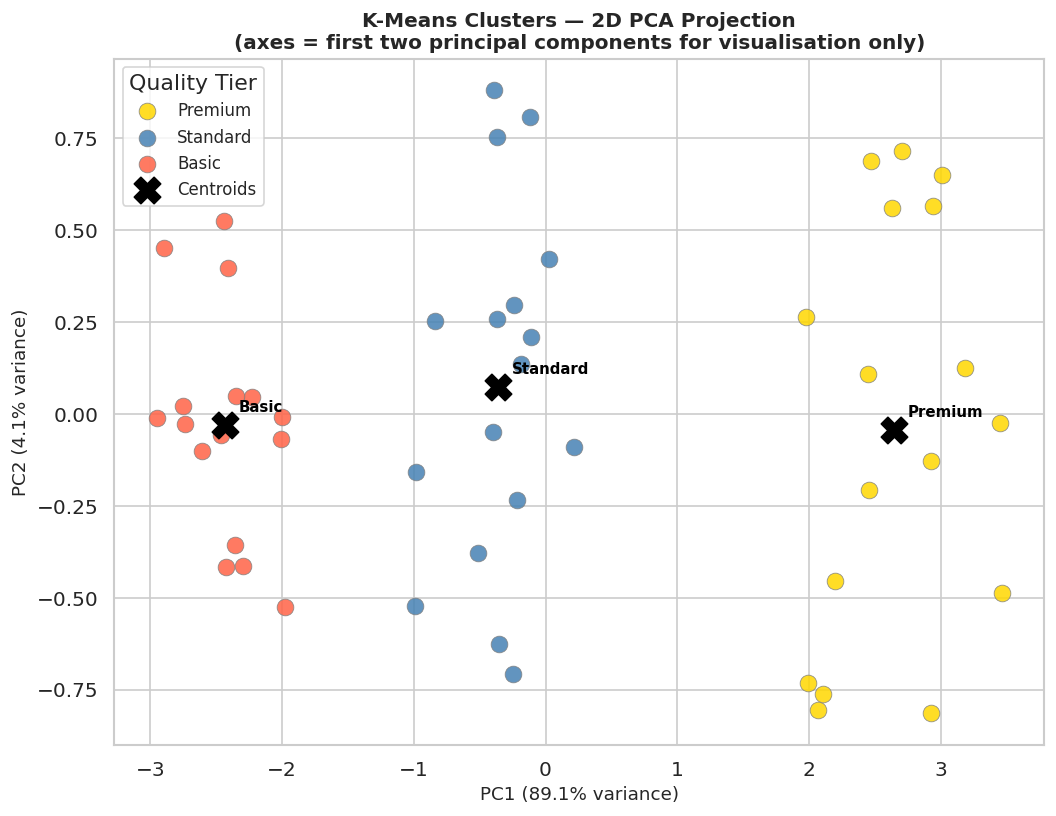

In [49]:
# Cluster Visualisations

TIER_COLOURS = {
    "Premium":  "gold",
    "Standard": "steelblue",
    "Basic":    "tomato"
}

# PCA 2D Cluster Scatter Plot
# NOTE: PCA used ONLY for visualisation, not for clustering

pca_vis   = PCA(n_components=2, random_state=random_state)
X_pca     = pca_vis.fit_transform(X_scaled)
pca_var   = pca_vis.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))

for tier in ["Premium", "Standard", "Basic"]:
    mask = data["qualityTier"] == tier
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=TIER_COLOURS[tier],
        label=tier,
        s=100,
        edgecolors="grey",
        linewidth=0.5,
        alpha=0.85,
        zorder=3
    )

# Plot centroids in PCA space
centroids_pca = pca_vis.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    c="black",
    zorder=5,
    label="Centroids"
)

# Annotate centroids with tier names
for cluster_id, (cx, cy) in enumerate(centroids_pca):
    tier_name = CLUSTER_TO_TIER[cluster_id]
    ax.annotate(
        tier_name,
        xy=(cx, cy),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

ax.set_xlabel(f"PC1 ({pca_var[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_var[1]*100:.1f}% variance)", fontsize=11)
ax.set_title(
    "K-Means Clusters — 2D PCA Projection\n"
    "(axes = first two principal components for visualisation only)",
    fontsize=12, fontweight="bold"
)
ax.legend(title="Quality Tier", fontsize=10)
plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_pca_scatter.png", bbox_inches="tight")
plt.show()

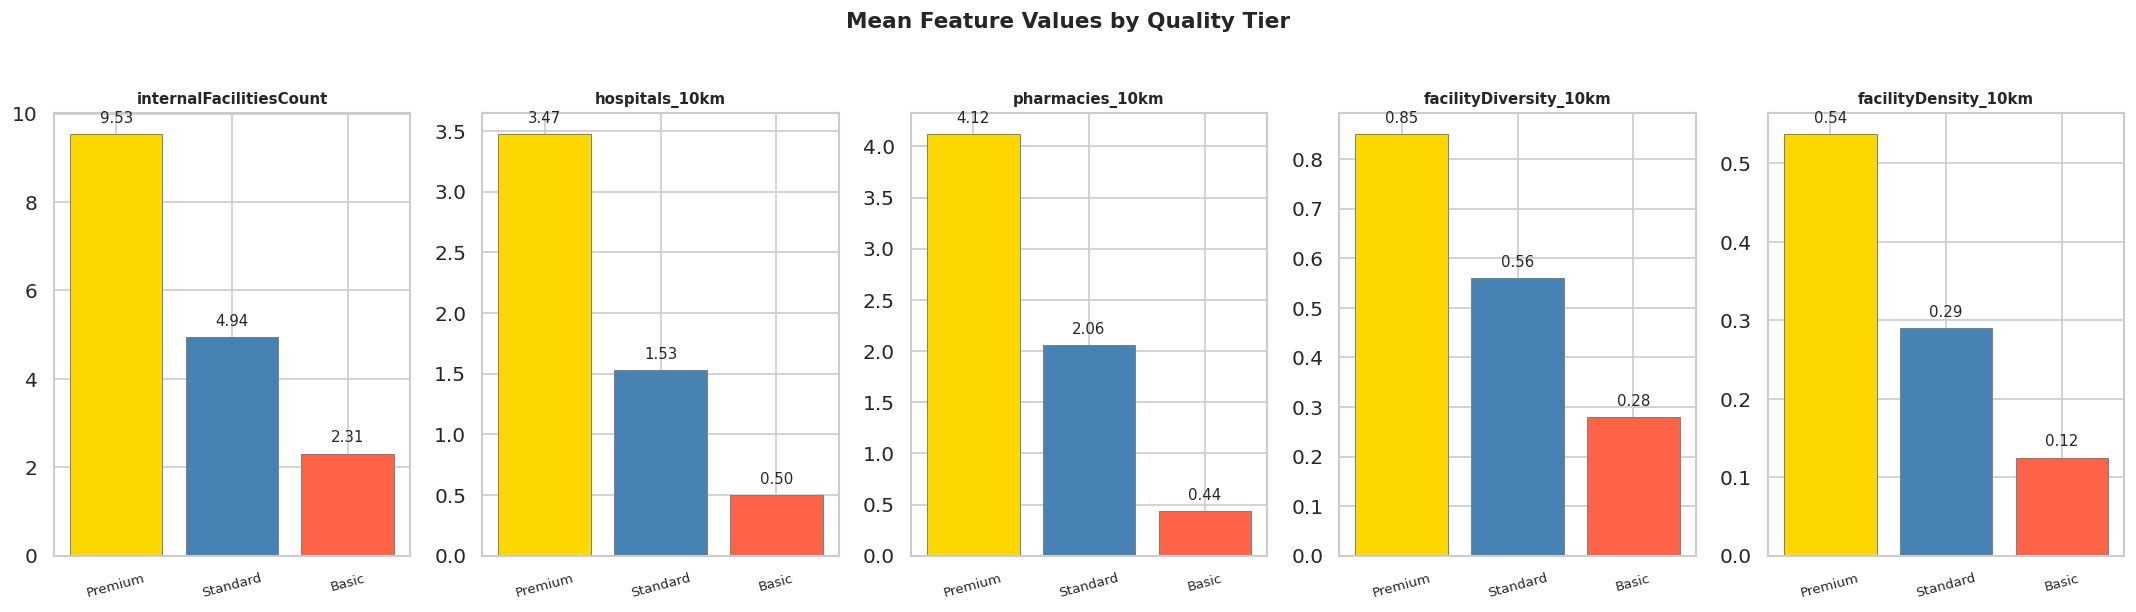

In [50]:
# Feature Mean Bar Chart by Tier
fig, axes = plt.subplots(1, len(SELECTED_FEATURES), figsize=(18, 5))

for i, feat in enumerate(SELECTED_FEATURES):
    tier_order = ["Premium", "Standard", "Basic"]
    values     = [tier_means.loc[t, feat] for t in tier_order]
    colours    = [TIER_COLOURS[t] for t in tier_order]

    bars = axes[i].bar(
        tier_order, values,
        color=colours,
        edgecolor="grey",
        linewidth=0.6
    )
    # Annotate bar heights
    for bar, val in zip(bars, values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02 * max(values),
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=9
        )
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", labelsize=8, rotation=15)

fig.suptitle(
    "Mean Feature Values by Quality Tier",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_tier_feature_means.png", bbox_inches="tight")
plt.show()

# This chart validates the tier mapping visually:
# For every feature bar chart, bars should follow the order: Premium (gold) > Standard (blue) > Basic (red)

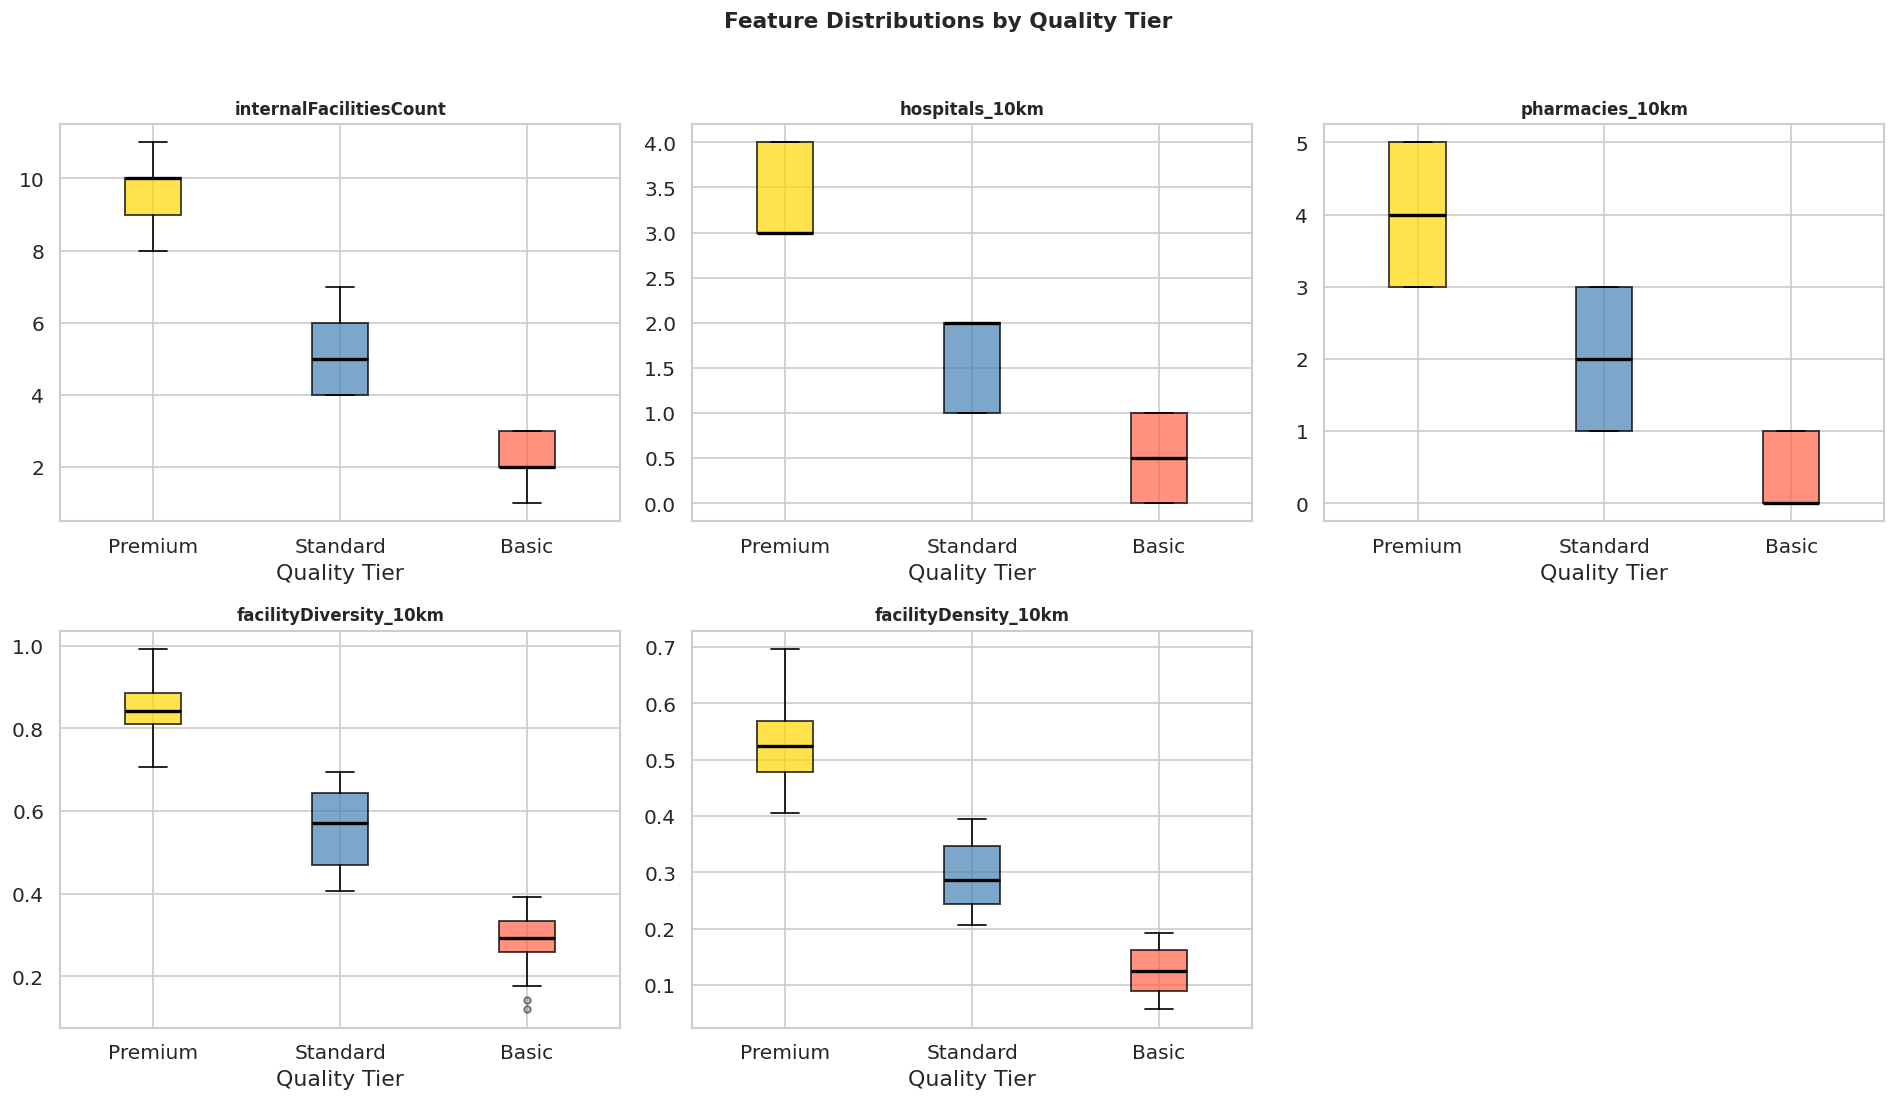

In [51]:
# Box Plots by Quality Tier
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(SELECTED_FEATURES):
    ax = axes[i]
    tier_data = [
        data.loc[data["qualityTier"] == tier, feat].values
        for tier in ["Premium", "Standard", "Basic"]
    ]
    bp = ax.boxplot(
        tier_data,
        labels=["Premium", "Standard", "Basic"],
        patch_artist=True,
        boxprops=dict(linewidth=1.2),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markersize=4, alpha=0.5)
    )
    # Apply tier colours to boxes
    for patch, colour in zip(bp["boxes"],
                             ["gold", "steelblue", "tomato"]):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)

    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel("Quality Tier")

axes[-1].set_visible(False)

fig.suptitle(
    "Feature Distributions by Quality Tier",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_tier_boxplots.png", bbox_inches="tight")
plt.show()


# Box plots reveal separation quality better than bar charts:
# Non-overlapping boxes = clean cluster boundaries = good clustering
# Heavily overlapping boxes = fuzzy boundaries = Standard tier challenge
# The Standard tier boxes are expected to partially overlap with both
# Premium and Basic: it occupies the middle ground by definition.

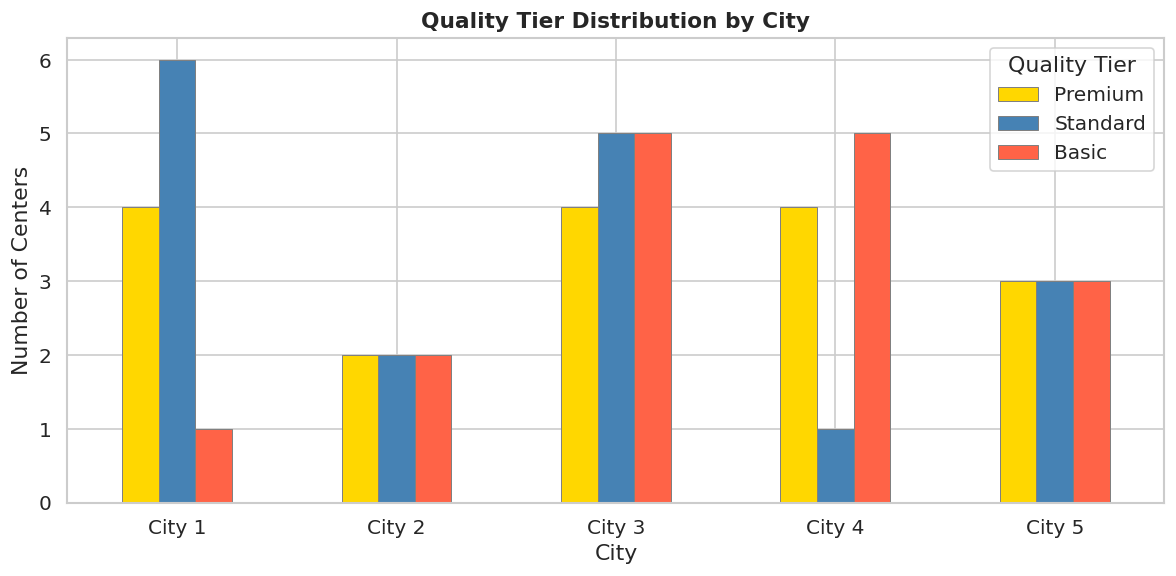

In [52]:
# Tier Distribution by City
city_tier = (
    data.groupby(["city", "qualityTier"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(10, 5))

city_pivot = city_tier.pivot(
    index="city", columns="qualityTier", values="count"
).fillna(0)[["Premium", "Standard", "Basic"]]

city_pivot.plot(
    kind="bar",
    ax=ax,
    color=["gold", "steelblue", "tomato"],
    edgecolor="grey",
    linewidth=0.6
)

ax.set_title(
    "Quality Tier Distribution by City",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("City")
ax.set_ylabel("Number of Centers")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Quality Tier")

plt.tight_layout()
plt.savefig("kmeans_visuals/kmeans_tier_by_city.png", bbox_inches="tight")
plt.show()

This chart directly answers the key business question:

- "Are Premium centers concentrated in specific cities?"
- If one city has exclusively Premium centers, geographic location may be acting as a hidden proxy for quality, a finding worth flagging.

All tiers appearing in all cities, confirming that quality is a center-level characteristic, not a city-level one.

In [53]:
# Save Model Artefacts & Export Results

# Save the trained model and scaler
joblib.dump(kmeans,  "baseline_models/kmeans_model.pkl")
joblib.dump(scaler,  "baseline_models/scaler.pkl")
joblib.dump(CLUSTER_TO_TIER, "baseline_models/cluster_to_tier.pkl")

print("   Model artefacts saved:")
print("   kmeans_model.pkl      → trained K-Means model")
print("   scaler.pkl            → fitted StandardScaler")
print("   cluster_to_tier.pkl   → cluster number → tier name mapping")

   Model artefacts saved:
   kmeans_model.pkl      → trained K-Means model
   scaler.pkl            → fitted StandardScaler
   cluster_to_tier.pkl   → cluster number → tier name mapping


In [54]:
# Export the labelled dataset
output_cols = [
    "researchCenterId",
    "researchCenterName",
    "city",
    "latitude",
    "longitude",
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
    "cluster",
    "qualityTier"
]

data[output_cols].to_csv("data/research_centers_clustered.csv", index=False)
print("\n Labelled dataset saved to data/research_centers_clustered.csv")
print(f"Columns added: 'cluster' and 'qualityTier'")


 Labelled dataset saved to data/research_centers_clustered.csv
Columns added: 'cluster' and 'qualityTier'
